In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

In [10]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)

In [11]:
from pathlib import Path

current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

figures_folder = project_root / "reports" / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

print("Figures folder:", figures_folder)

Figures folder: c:\Github\retail-financial-intelligence\reports\figures


In [12]:
project_root = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

master_file = (
    project_root
    / "data"
    / "processed"
    / "retailiq_cleaned_master.csv.gz"
)

clean_df = pd.read_csv(
    master_file,
    compression="gzip",
    parse_dates=["InvoiceDate"],
    low_memory=False
)

# Restore the nullable integer datatype
clean_df["CustomerID"] = pd.to_numeric(
    clean_df["CustomerID"],
    errors="coerce"
).astype("Int64")

print("File loaded successfully:", master_file)
print("Dataset shape:", clean_df.shape)
print(
    "Date range:",
    clean_df["InvoiceDate"].min(),
    "to",
    clean_df["InvoiceDate"].max()
)

clean_df.head()

File loaded successfully: c:\Github\retail-financial-intelligence\data\processed\retailiq_cleaned_master.csv.gz
Dataset shape: (1033036, 29)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType,DQ_ExtremeQuantity,DQ_ExtremePrice,DQ_ExtremeRevenue,DQ_CriticalMissing,DQ_MissingDescription,DQ_MissingCustomerID,DQ_RevenueMismatch,DQ_SaleRuleViolation,DQ_CancellationException,DQ_OtherNeedsReview,ExactReversalPairID,ReversalRole,IsExactReversalPair
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,False,False,False,False,True,85048,Sale,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,False,False,False,False,True,79323P,Sale,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,False,False,False,False,True,79323W,Sale,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,False,False,False,False,True,22041,Sale,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,False,False,False,False,True,21232,Sale,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False


In [13]:
# Completed product sales
product_sales_df = clean_df.loc[
    clean_df["TransactionType"].eq("Sale")
].copy()

# Product sales made by identified customers
customer_sales_df = product_sales_df.loc[
    product_sales_df["CustomerID"].notna()
].copy()

# Product sales and cancellations
net_product_transactions_df = clean_df.loc[
    clean_df["TransactionType"].isin([
        "Sale",
        "Cancellation"
    ])
].copy()

#financial activity
financial_activity_types = [
    "Postage and Carrier charges",
    "Manual",
    "Discount",
    "Bank Charges",
    "Financial Adjustment",
    "Commission charges",
    "Bad Debt"
]

financial_activity_df = clean_df.loc[
    clean_df["TransactionType"].isin(
        financial_activity_types
    )
].copy()

#Transactions classified as "Other" in the TransactionType column
other_review_df = clean_df.loc[
    clean_df["TransactionType"].eq("Other")
].copy()


In [14]:
financial_activity_summary = (
    financial_activity_df
    .groupby("TransactionType")
    .agg(
        Rows=("Invoice", "size"),
        Invoices=("Invoice", "nunique"),
        TotalRevenue=("Revenue", "sum"),
        AverageRevenue=("Revenue", "mean")
    )
    .sort_values("TotalRevenue", ascending=False)
)

financial_activity_summary.round(2)

,Rows,Invoices,TotalRevenue,AverageRevenue
TransactionType,,,,
Postage and Carrier charges,3788,3783,"433,410.51",114.42
Financial Adjustment,70,70,"7,566.29",108.09
Discount,173,151,"-12,879.63",-74.45
Bank Charges,100,95,"-35,482.25",-354.82
Manual,1392,1290,"-83,311.28",-59.85
Bad Debt,6,6,"-147,614.08","-24,602.35"
Commission charges,36,36,"-221,520.50","-6,153.35"


In [15]:
eda_view_validation = pd.Series({
    "All cleaned rows": len(clean_df),
    "Product sales": len(product_sales_df),
    "Known-customer sales": len(customer_sales_df),
    "Sales and cancellations": len(
        net_product_transactions_df
    ),
    "Missing IDs in customer_sales_df": (
        customer_sales_df["CustomerID"].isna().sum()
    ),
    "Non-sale rows in product_sales_df": (
        ~product_sales_df["TransactionType"].eq("Sale")
    ).sum()
})

eda_view_validation

All cleaned rows                     1033036
Product sales                        1003437
Known-customer sales                  776596
Sales and cancellations              1021467
Missing IDs in customer_sales_df           0
Non-sale rows in product_sales_df          0
dtype: int64

In [16]:
clean_df[
    [
        "Invoice",
        "StockCode",
        "StockCodeNormalized",
        "InvoiceDate",
        "CustomerID",
        "Quantity",
        "Price",
        "Revenue",
        "TransactionType"
    ]
].dtypes

Invoice                           str
StockCode                         str
StockCodeNormalized               str
InvoiceDate            datetime64[us]
CustomerID                      Int64
Quantity                        int64
Price                         float64
Revenue                       float64
TransactionType                   str
dtype: object

<Axes: title={'center': 'Transaction Type Distribution'}, xlabel='TransactionType'>

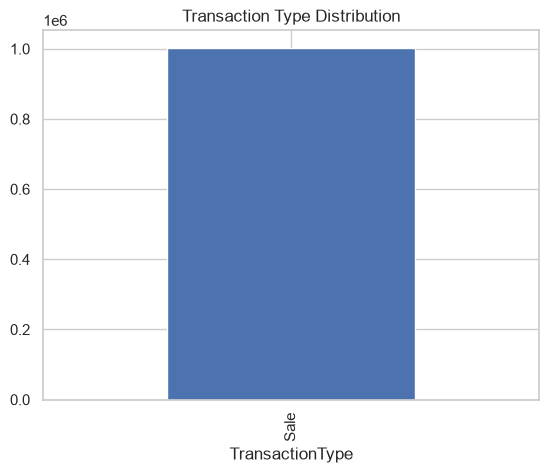

In [17]:
product_sales_df.TransactionType.value_counts().plot(kind="bar", title="Transaction Type Distribution")

<Axes: title={'center': 'Transaction Type Distribution'}, xlabel='TransactionType'>

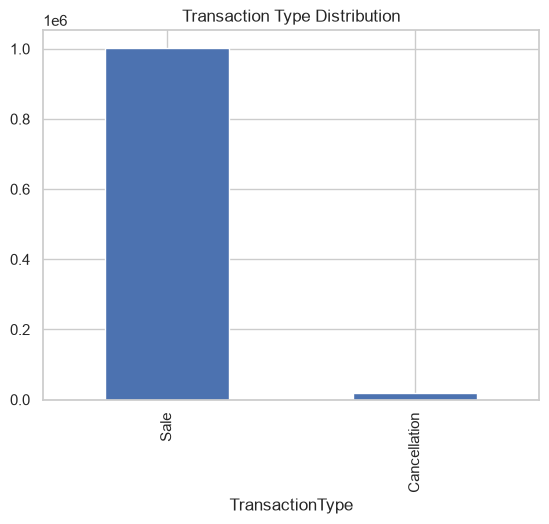

In [18]:
net_product_transactions_df.TransactionType.value_counts().plot(kind="bar", title="Transaction Type Distribution")

<Axes: title={'center': 'Transaction Type Distribution'}, xlabel='TransactionType'>

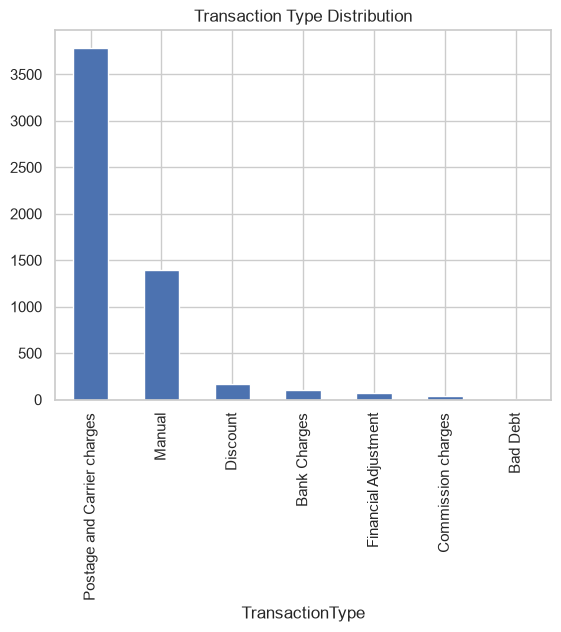

In [19]:
financial_activity_df.TransactionType.value_counts().plot(kind="bar", title="Transaction Type Distribution")

Check the reporting period

In [20]:
reporting_period = pd.Series({
    "Start date": product_sales_df["InvoiceDate"].min(),
    "End date": product_sales_df["InvoiceDate"].max(),
    "Calendar days": (
        product_sales_df["InvoiceDate"].max()
        - product_sales_df["InvoiceDate"].min()
    ).days + 1,
    "Transaction days": (
        product_sales_df["InvoiceDate"]
        .dt.normalize()
        .nunique()
    )
})

reporting_period

Start date          2009-12-01 07:45:00
End date            2011-12-09 12:50:00
Calendar days                       739
Transaction days                    604
dtype: object

In [21]:
start_month = (
    product_sales_df["InvoiceDate"]
    .min()
    .to_period("M")
)

end_month = (
    product_sales_df["InvoiceDate"]
    .max()
    .to_period("M")
)

print("First reporting month:", start_month)
print("Last reporting month:", end_month)
print(
    "Last month ends on day:",
    product_sales_df["InvoiceDate"].max().day
)

First reporting month: 2009-12
Last reporting month: 2011-12
Last month ends on day: 9


Calculate baseline KPIs

In [22]:
order_summary = (
    product_sales_df
    .groupby("Invoice")
    .agg(
        OrderDate=("InvoiceDate", "min"),
        CustomerID=("CustomerID", "first"),
        OrderRevenue=("Revenue", "sum"),
        Units=("Quantity", "sum"),
        ProductLines=("StockCode", "size"),
        UniqueProducts=("StockCode", "nunique")
    )
    .reset_index()
)

In [23]:
order_summary

,Invoice,OrderDate,CustomerID,OrderRevenue,Units,ProductLines,UniqueProducts
0,489434,2009-12-01 07:45:00,13085,505.30,166,8,8
1,489435,2009-12-01 07:46:00,13085,145.80,60,4,4
2,489436,2009-12-01 09:06:00,13078,630.33,193,19,19
3,489437,2009-12-01 09:08:00,15362,310.75,145,23,23
4,489438,2009-12-01 09:24:00,18102,"2,286.24",826,17,17
...,...,...,...,...,...,...,...
39514,581583,2011-12-09 12:23:00,13777,124.60,76,2,2
39515,581584,2011-12-09 12:25:00,13777,140.64,120,2,2
39516,581585,2011-12-09 12:31:00,15804,329.05,278,21,21
39517,581586,2011-12-09 12:49:00,13113,339.20,66,4,4


Calculate cancellation values separately:

In [24]:
cancellation_df = (
    net_product_transactions_df.loc[
        net_product_transactions_df[
            "TransactionType"
        ].eq("Cancellation")
    ]
)

recorded_sale_df = (
    net_product_transactions_df.loc[
        net_product_transactions_df[
            "TransactionType"
        ].eq("Sale")
    ]
)

In [25]:
baseline_kpis = pd.Series({
    "Completed product-sale rows":
        len(product_sales_df),

    "Completed orders":
        product_sales_df["Invoice"].nunique(),

    "Unique products":
        product_sales_df["StockCode"].nunique(),

    "Known customers":
        product_sales_df["CustomerID"].nunique(),

    "Units sold":
        product_sales_df["Quantity"].sum(),

    "Completed product revenue":
        product_sales_df["Revenue"].sum(),

    "Average order value":
        order_summary["OrderRevenue"].mean(),

    "Median order value":
        order_summary["OrderRevenue"].median(),

    "Recorded gross product revenue":
        recorded_sale_df["Revenue"].sum(),

    "Cancellation impact":
        cancellation_df["Revenue"].sum(),

    "Recorded net product revenue":
        net_product_transactions_df["Revenue"].sum(),

    "Cancellation invoices":
        cancellation_df["Invoice"].nunique()
})

baseline_kpis

Completed product-sale rows       1,003,437.00
Completed orders                     39,519.00
Unique products                       4,904.00
Known customers                       5,852.00
Units sold                       11,188,144.00
Completed product revenue        19,645,754.66
Average order value                     497.12
Median order value                      301.20
Recorded gross product revenue   19,645,754.66
Cancellation impact                -730,593.52
Recorded net product revenue     18,915,161.14
Cancellation invoices                 7,457.00
dtype: float64

Validate the KPI population

In [26]:
kpi_validation = {
    "product_sales_are_positive": bool(
        (product_sales_df["Revenue"] > 0).all()
    ),

    "no_cancelled_completed_sales": bool(
        ~product_sales_df["IsCancelled"].any()
    ),

    "no_re_no_exact_reversals": bool(
        ~product_sales_df[
            "IsExactReversalPair"
        ].any()
    ),

    "orders_are_unique": bool(
        order_summary["Invoice"].is_unique
    ),

    "dates_are_available": bool(
        product_sales_df["InvoiceDate"]
        .notna()
        .all()
    )
}

kpi_validation

{'product_sales_are_positive': True,
 'no_cancelled_completed_sales': True,
 'no_re_no_exact_reversals': False,
 'orders_are_unique': True,
 'dates_are_available': True}

Create monthly KPIs

In [27]:

product_monthly = (
    product_sales_df
    .assign(
        Month=product_sales_df[
            "InvoiceDate"
        ].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("Month")
    .agg(
        CompletedRevenue=("Revenue", "sum"),
        CompletedOrders=("Invoice", "nunique"),
        UnitsSold=("Quantity", "sum"),
        ActiveCustomers=("CustomerID", "nunique"),
        UniqueProducts=("StockCode", "nunique")
    )
)

Create recorded gross, cancellation and net revenue:

In [28]:
monthly_source = (
    net_product_transactions_df.copy()
)

monthly_source["Month"] = (
    monthly_source["InvoiceDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_source["RecordedGrossRevenue"] = np.where(
    monthly_source["TransactionType"].eq("Sale"),
    monthly_source["Revenue"],
    0
)

monthly_source["CancellationRevenue"] = np.where(
    monthly_source["TransactionType"].eq(
        "Cancellation"
    ),
    monthly_source["Revenue"],
    0
)

monthly_source["CancellationInvoice"] = (
    monthly_source["Invoice"].where(
        monthly_source["TransactionType"].eq(
            "Cancellation"
        )
    )
)

recorded_monthly = (
    monthly_source
    .groupby("Month")
    .agg(
        RecordedGrossRevenue=(
            "RecordedGrossRevenue",
            "sum"
        ),
        CancellationRevenue=(
            "CancellationRevenue",
            "sum"
        ),
        RecordedNetRevenue=("Revenue", "sum"),
        CancellationInvoices=(
            "CancellationInvoice",
            "nunique"
        )
    )
)   

In [29]:
monthly_kpis = (
    product_monthly
    .join(recorded_monthly, how="outer")
    .sort_index()
)

numeric_columns = monthly_kpis.select_dtypes(
    include="number"
).columns

monthly_kpis[numeric_columns] = (
    monthly_kpis[numeric_columns].fillna(0)
)

Mark partial months

In [30]:
start_date = product_sales_df[
    "InvoiceDate"
].min()

end_date = product_sales_df[
    "InvoiceDate"
].max()

monthly_kpis["IsPartialMonth"] = False

if start_date.day != 1:
    monthly_kpis.loc[
        monthly_kpis.index.to_period("M")
        == start_date.to_period("M"),
        "IsPartialMonth"
    ] = True

if end_date.day != end_date.days_in_month:
    monthly_kpis.loc[
        monthly_kpis.index.to_period("M")
        == end_date.to_period("M"),
        "IsPartialMonth"
    ] = True

Calculate growth and cancellation impact:

In [31]:
monthly_kpis["RevenueMoMPercent"] = (
    monthly_kpis["CompletedRevenue"]
    .pct_change()
    .mul(100)
)

monthly_kpis["CancellationRatePercent"] = (
    monthly_kpis["CancellationRevenue"]
    .abs()
    .div(
        monthly_kpis[
            "RecordedGrossRevenue"
        ].replace(0, np.nan)
    )
    .mul(100)
)

monthly_kpis.loc[
    monthly_kpis["IsPartialMonth"],
    "RevenueMoMPercent"
] = np.nan

monthly_kpis.tail(8)

,CompletedRevenue,CompletedOrders,UnitsSold,ActiveCustomers,UniqueProducts,RecordedGrossRevenue,CancellationRevenue,RecordedNetRevenue,CancellationInvoices,IsPartialMonth,RevenueMoMPercent,CancellationRatePercent
Month,,,,,,,,,,,,
2011-05-01,"740,036.33",1668,394657,1054,2453,"740,036.33","-9,367.78","730,668.55",270,False,43.56,1.27
2011-06-01,"737,683.99",1525,388129,990,2621,"737,683.99","-14,339.35","723,344.64",301,False,-0.32,1.94
2011-07-01,"688,252.67",1452,399292,946,2666,"688,252.67","-11,407.26","676,845.41",236,False,-6.70,1.66
2011-08-01,"724,308.16",1339,420701,933,2591,"724,308.16","-23,727.37","700,580.79",243,False,5.24,3.28
2011-09-01,"1,028,345.38",1818,568702,1259,2728,"1,028,345.38","-18,118.07","1,010,227.31",304,False,41.98,1.76
2011-10-01,"1,103,363.97",2006,619599,1361,2852,"1,103,363.97","-44,097.75","1,059,266.22",316,False,7.30,4.00
2011-11-01,"1,452,115.98",2751,746952,1660,2934,"1,452,115.98","-28,468.65","1,423,647.33",401,False,31.61,1.96
2011-12-01,"614,499.25",816,312648,614,2465,"614,499.25","-175,191.80","439,307.45",138,True,NaN,28.51


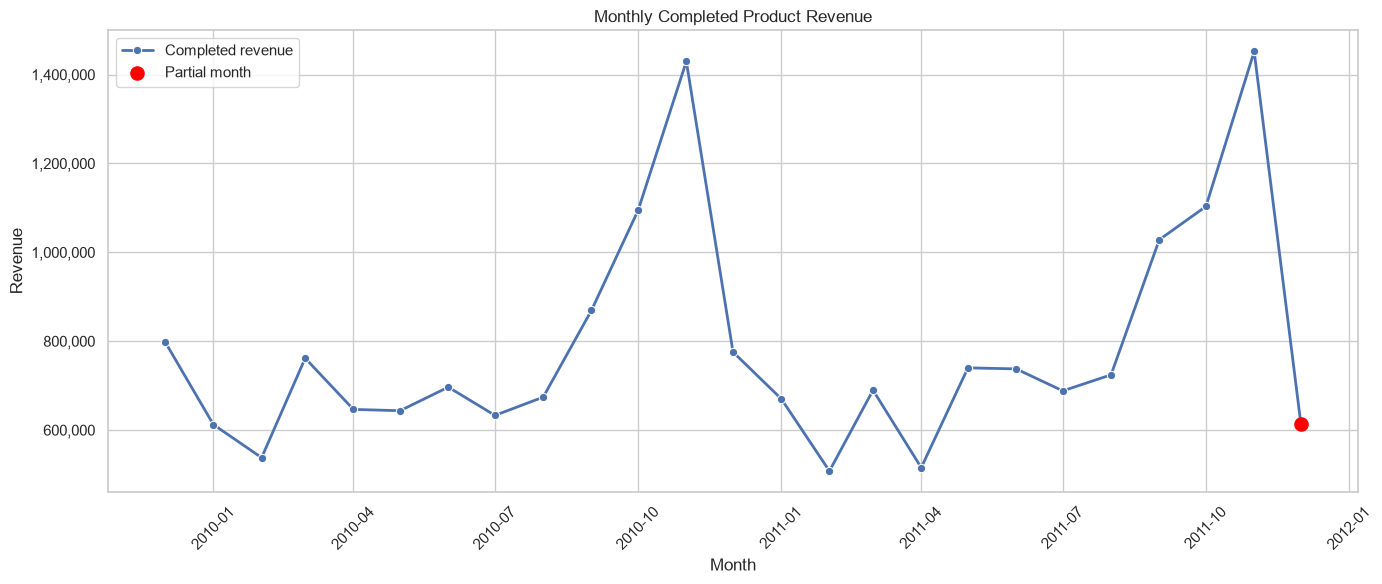

In [32]:
from matplotlib.ticker import StrMethodFormatter

plot_data = monthly_kpis.reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=plot_data,
    x="Month",
    y="CompletedRevenue",
    marker="o",
    linewidth=2,
    label="Completed revenue",
    ax=ax
)

partial_data = plot_data.loc[
    plot_data["IsPartialMonth"]
]

ax.scatter(
    partial_data["Month"],
    partial_data["CompletedRevenue"],
    color="red",
    s=90,
    zorder=5,
    label="Partial month"
)

ax.set_title("Monthly Completed Product Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()



plt.savefig(
    figures_folder / "monthly_completed_product_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Identify strongest months (using only complete months) Top 5

In [33]:
complete_months = monthly_kpis.loc[
    ~monthly_kpis["IsPartialMonth"]
].copy()

complete_months.nlargest(
    5,
    "CompletedRevenue"
)[
    [
        "CompletedRevenue",
        "CompletedOrders",
        "UnitsSold",
        "ActiveCustomers",
        "RevenueMoMPercent"
    ]
]

,CompletedRevenue,CompletedOrders,UnitsSold,ActiveCustomers,RevenueMoMPercent
Month,,,,,
2011-11-01,"1,452,115.98",2751,746952,1660,31.61
2010-11-01,"1,429,751.84",2719,724268,1606,30.62
2011-10-01,"1,103,363.97",2006,619599,1361,7.30
2010-10-01,"1,094,563.63",2244,619515,1492,25.92
2011-09-01,"1,028,345.38",1818,568702,1259,41.98


the weakest complete months Least 5

In [34]:
complete_months.nsmallest(
    5,
    "CompletedRevenue"
)[
    [
        "CompletedRevenue",
        "CompletedOrders",
        "UnitsSold",
        "ActiveCustomers",
        "RevenueMoMPercent"
    ]
]

,CompletedRevenue,CompletedOrders,UnitsSold,ActiveCustomers,RevenueMoMPercent
Month,,,,,
2011-02-01,"507,866.54",1093,282630,757,-24.25
2011-04-01,"515,499.66",1236,307657,853,-25.27
2010-02-01,"537,926.70",1189,381627,771,-12.16
2010-01-01,"612,365.50",1049,390417,701,-23.27
2010-07-01,"633,079.42",1507,337560,924,-9.13


Cancellation and return-risk analysis
Cancellation counts alone are misleading, so measure both the volume and financial impact.

Overall cancellation KPIs

In [35]:
sale_mask = (
    net_product_transactions_df[
        "TransactionType"
    ].eq("Sale")
)

cancellation_mask = (
    net_product_transactions_df[
        "TransactionType"
    ].eq("Cancellation")
)

gross_revenue = (
    net_product_transactions_df.loc[
        sale_mask, "Revenue"
    ].sum()
)

cancellation_value = abs(
    net_product_transactions_df.loc[
        cancellation_mask, "Revenue"
    ].sum()
)

cancellation_summary = pd.Series({
    "Recorded sale rows":
        sale_mask.sum(),

    "Cancellation rows":
        cancellation_mask.sum(),

    "Sale invoices":
        net_product_transactions_df.loc[
            sale_mask, "Invoice"
        ].nunique(),

    "Cancellation invoices":
        net_product_transactions_df.loc[
            cancellation_mask, "Invoice"
        ].nunique(),

    "Cancelled units":
        abs(
            net_product_transactions_df.loc[
                cancellation_mask,
                "Quantity"
            ].sum()
        ),

    "Gross recorded revenue":
        gross_revenue,

    "Cancellation value":
        cancellation_value,

    "Net product revenue":
        net_product_transactions_df[
            "Revenue"
        ].sum(),

    "Cancellation revenue rate (%)":
        (
            cancellation_value / gross_revenue * 100
            if gross_revenue != 0
            else np.nan
        )
})

cancellation_summary

Recorded sale rows               1,003,437.00
Cancellation rows                   18,030.00
Sale invoices                       39,519.00
Cancellation invoices                7,457.00
Cancelled units                    467,855.00
Gross recorded revenue          19,645,754.66
Cancellation value                 730,593.52
Net product revenue             18,915,161.14
Cancellation revenue rate (%)            3.72
dtype: float64

Analyse monthly cancellation rates

In [36]:
monthly_kpis[
    [
        "RecordedGrossRevenue",
        "CancellationRevenue",
        "RecordedNetRevenue",
        "CancellationInvoices",
        "CancellationRatePercent",
        "IsPartialMonth"
    ]
].tail(12)

,RecordedGrossRevenue,CancellationRevenue,RecordedNetRevenue,CancellationInvoices,CancellationRatePercent,IsPartialMonth
Month,,,,,,
2011-01-01,"670,439.46","-91,525.05","578,914.41",247,13.65,False
2011-02-01,"507,866.54","-9,144.20","498,722.34",195,1.80,False
2011-03-01,"689,841.84","-10,621.14","679,220.70",282,1.54,False
2011-04-01,"515,499.66","-33,316.06","482,183.60",220,6.46,False
2011-05-01,"740,036.33","-9,367.78","730,668.55",270,1.27,False
2011-06-01,"737,683.99","-14,339.35","723,344.64",301,1.94,False
2011-07-01,"688,252.67","-11,407.26","676,845.41",236,1.66,False
2011-08-01,"724,308.16","-23,727.37","700,580.79",243,3.28,False
2011-09-01,"1,028,345.38","-18,118.07","1,010,227.31",304,1.76,False


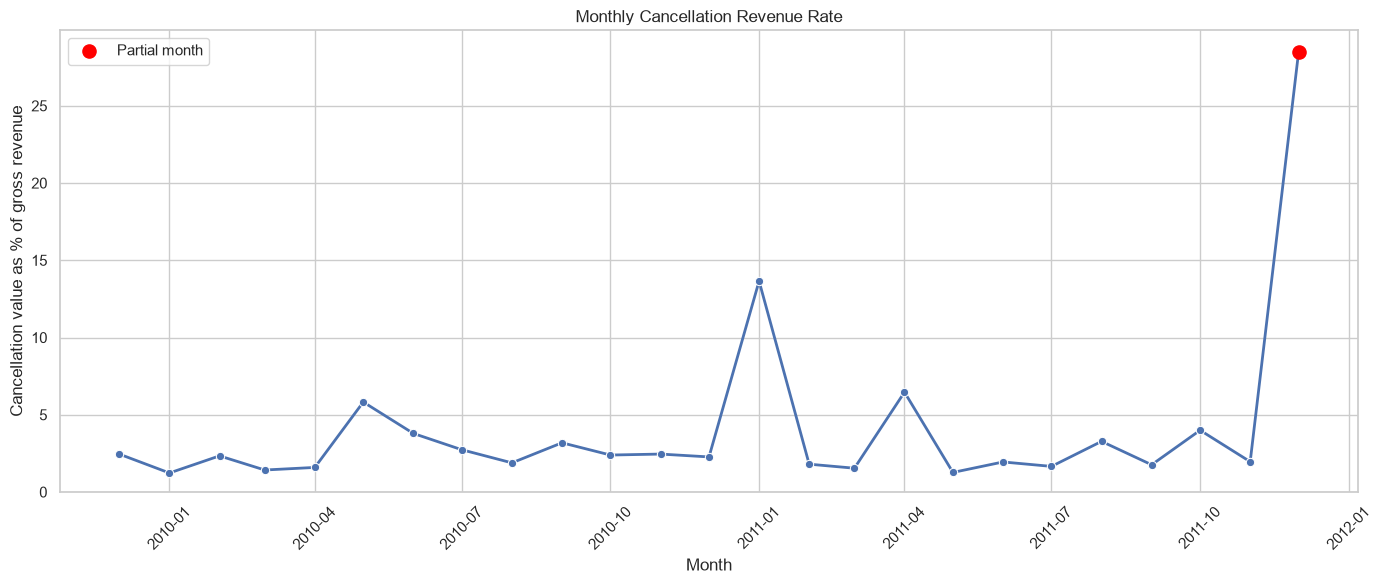

In [37]:
cancellation_plot = (
    monthly_kpis
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=cancellation_plot,
    x="Month",
    y="CancellationRatePercent",
    marker="o",
    linewidth=2,
    ax=ax
)

partial_rows = cancellation_plot.loc[
    cancellation_plot["IsPartialMonth"]
]

ax.scatter(
    partial_rows["Month"],
    partial_rows["CancellationRatePercent"],
    color="red",
    s=90,
    zorder=5,
    label="Partial month"
)

ax.set_title("Monthly Cancellation Revenue Rate")
ax.set_xlabel("Month")
ax.set_ylabel("Cancellation value as % of gross revenue")
ax.set_ylim(bottom=0)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()


plt.savefig(
    figures_folder / "monthly_cancellation_revenue_rate.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Find the highest-risk complete months:

In [38]:
monthly_kpis.loc[
    ~monthly_kpis["IsPartialMonth"]
].nlargest(
    5,
    "CancellationRatePercent"
)[
    [
        "RecordedGrossRevenue",
        "CancellationRevenue",
        "CancellationInvoices",
        "CancellationRatePercent"
    ]
]

,RecordedGrossRevenue,CancellationRevenue,CancellationInvoices,CancellationRatePercent
Month,,,,
2011-01-01,"670,439.46","-91,525.05",247,13.65
2011-04-01,"515,499.66","-33,316.06",220,6.46
2010-05-01,"643,585.64","-37,476.33",390,5.82
2011-10-01,"1,103,363.97","-44,097.75",316,4.00
2010-06-01,"696,651.27","-26,400.11",320,3.79


Calculate product-level cancellation risk

In [39]:
product_risk_source = (
    net_product_transactions_df.copy()
)

is_sale = product_risk_source[
    "TransactionType"
].eq("Sale")

is_cancellation = product_risk_source[
    "TransactionType"
].eq("Cancellation")

product_risk_source["GrossUnits"] = np.where(
    is_sale,
    product_risk_source["Quantity"],
    0
)

product_risk_source["CancelledUnits"] = np.where(
    is_cancellation,
    product_risk_source["Quantity"].abs(),
    0
)

product_risk_source["GrossRevenue"] = np.where(
    is_sale,
    product_risk_source["Revenue"],
    0
)

product_risk_source["CancellationValue"] = np.where(
    is_cancellation,
    product_risk_source["Revenue"].abs(),
    0
)

product_risk_source["SaleInvoice"] = (
    product_risk_source["Invoice"].where(is_sale)
)

product_risk_source["CancellationInvoice"] = (
    product_risk_source["Invoice"].where(
        is_cancellation
    )
)

Create a standard description for each stock code

In [40]:
description_lookup = (
    product_sales_df
    .dropna(subset=["Description"])
    .groupby(
        ["StockCode", "Description"]
    )
    .size()
    .reset_index(name="Rows")
    .sort_values(
        ["StockCode", "Rows"],
        ascending=[True, False]
    )
    .drop_duplicates("StockCode")
    .set_index("StockCode")["Description"]
)

In [41]:
product_cancellation_risk = (
    product_risk_source
    .groupby("StockCode")
    .agg(
        GrossUnits=("GrossUnits", "sum"),
        CancelledUnits=("CancelledUnits", "sum"),
        GrossRevenue=("GrossRevenue", "sum"),
        CancellationValue=(
            "CancellationValue",
            "sum"
        ),
        SaleInvoices=("SaleInvoice", "nunique"),
        CancellationInvoices=(
            "CancellationInvoice",
            "nunique"
        )
    )
    .join(description_lookup)
)

product_cancellation_risk[
    "UnitCancellationRatePercent"
] = (
    product_cancellation_risk["CancelledUnits"]
    .div(
        product_cancellation_risk[
            "GrossUnits"
        ].replace(0, np.nan)
    )
    .mul(100)
)

product_cancellation_risk[
    "RevenueCancellationRatePercent"
] = (
    product_cancellation_risk[
        "CancellationValue"
    ]
    .div(
        product_cancellation_risk[
            "GrossRevenue"
        ].replace(0, np.nan)
    )
    .mul(100)
)

In [42]:
product_cancellation_risk.nlargest(10, "CancelledUnits")

,GrossUnits,CancelledUnits,GrossRevenue,CancellationValue,SaleInvoices,CancellationInvoices,Description,UnitCancellationRatePercent,RevenueCancellationRatePercent
StockCode,,,,,,,,,
23843,80995,80995,"168,469.60","168,469.60",1,1,"PAPER CRAFT , LITTLE BIRDIE",100.00,100.00
23166,78033,74494,"81,700.92","77,479.64",247,10,MEDIUM CERAMIC TOP STORAGE JAR,95.46,94.83
84347,31409,9381,"71,300.40",330.45,756,6,ROTATING SILVER ANGELS T-LIGHT HLDR,29.87,0.46
21088,16615,7140,"1,816.73",572.52,136,2,SET/6 FRUIT SALAD PAPER CUPS,42.97,31.51
21096,15919,7008,"2,711.71",911.04,143,1,SET/6 FRUIT SALAD PAPER PLATES,44.02,33.60
16047,10612,5184,"1,054.70",414.72,31,1,POP ART PEN CASE & PENS,48.85,39.32
85110,11520,5040,"1,138.04",387.36,23,2,BLACK SILVER FLOWER T-LIGHT HOLDER,43.75,34.04
37340,13665,4996,"3,881.33",501.22,204,4,MULTICOLOUR SPRING FLOWER MUG,36.56,12.91
16046,10056,4632,"1,223.50",389.04,59,2,TEATIME PEN CASE & PENS,46.06,31.80


In [43]:
product_cancellation_risk.nsmallest(10, "CancelledUnits")

,GrossUnits,CancelledUnits,GrossRevenue,CancellationValue,SaleInvoices,CancellationInvoices,Description,UnitCancellationRatePercent,RevenueCancellationRatePercent
StockCode,,,,,,,,,
10002R,4,0,20.57,0.00,3,0,ROBOT PENCIL SHARPNER,0.00,0.00
10080,315,0,129.29,0.00,27,0,GROOVY CACTUS INFLATABLE,0.00,0.00
10109,4,0,1.68,0.00,1,0,BENDY COLOUR PENCILS,0.00,0.00
10124A,58,0,24.36,0.00,18,0,SPOTS ON RED BOOKCOVER TAPE,0.00,0.00
10124G,33,0,14.28,0.00,10,0,ARMY CAMO BOOKCOVER TAPE,0.00,0.00
10125,2103,0,"1,715.78",0.00,167,0,MINI FUNKY DESIGN TAPES,0.00,0.00
15030,254,0,73.66,0.00,26,0,FAN BLACK FRAME,0.00,0.00
15056bl,116,0,"1,456.32",0.00,87,0,EDWARDIAN PARASOL BLACK,0.00,0.00
15056n,173,0,"2,170.40",0.00,116,0,EDWARDIAN PARASOL NATURAL,0.00,0.00


Rank meaningful product risks

Require at least five sale invoices and 20 sold units to avoid unstable rates:

In [44]:
reliable_product_risk = (
    product_cancellation_risk.loc[
        (
            product_cancellation_risk[
                "SaleInvoices"
            ] >= 5
        )
        &
        (
            product_cancellation_risk[
                "GrossUnits"
            ] >= 20
        )
    ]
)

Top 15 cancelled products

In [45]:
top_cancelled_products = (
    reliable_product_risk
    .nlargest(15, "CancellationValue")
    [
        [
            "Description",
            "GrossUnits",
            "CancelledUnits",
            "GrossRevenue",
            "CancellationValue",
            "UnitCancellationRatePercent"
        ]
    ]
)

top_cancelled_products

,Description,GrossUnits,CancelledUnits,GrossRevenue,CancellationValue,UnitCancellationRatePercent
StockCode,,,,,,
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,74494,"81,700.92","77,479.64",95.46
22423,REGENCY CAKESTAND 3 TIER,26478,1450,"330,590.32","16,545.30",5.48
85123A,WHITE HANGING HEART T-LIGHT HOLDER,94203,3637,"257,724.71","9,387.10",3.86
71477,COLOUR GLASS. STAR T-LIGHT HOLDER,15089,2574,"44,680.75","7,164.12",17.06
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,12962,3159,"25,407.27","6,614.37",24.37
79323W,WHITE CHERRY LIGHTS,3004,1088,"18,048.72","6,421.10",36.22
21843,RED RETROSPOT CAKE STAND,6128,587,"64,918.30","5,270.25",9.58
84078A,SET/4 WHITE RETRO STORAGE CUBES,1128,147,"43,844.96","5,187.65",13.03
23113,PANTRY CHOPPING BOARD,1154,946,"5,868.50","4,803.06",81.98


In [46]:
top_cancelled_products.nlargest(1,"CancelledUnits")
print("Most cancelled product:", top_cancelled_products.iloc[0]["Description"])

Most cancelled product: MEDIUM CERAMIC TOP STORAGE JAR


Country and geographic performance

In [47]:
country_sales_source = product_sales_df.copy()

country_sales_source["CountryAnalysis"] = (
    country_sales_source["Country"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .fillna("Unknown")
)

Calculate country sales KPIs

In [48]:
country_performance = (
    country_sales_source
    .groupby("CountryAnalysis")
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique"),
        ProductLines=("StockCode", "size"),
        KnownCustomerRows=("CustomerID", "count")
    )
)

country_performance["AverageOrderValue"] = (
    country_performance["Revenue"]
    / country_performance["Orders"]
)

country_performance["RevenuePerCustomer"] = (
    country_performance["Revenue"]
    / country_performance[
        "Customers"
    ].replace(0, np.nan)
)

country_performance["RevenueSharePercent"] = (
    country_performance["Revenue"]
    / country_performance["Revenue"].sum()
    * 100
)

country_performance[
    "CustomerDataCoveragePercent"
] = (
    country_performance["KnownCustomerRows"]
    / country_performance["ProductLines"]
    * 100
)

country_performance = (
    country_performance
    .sort_values("Revenue", ascending=False)
)

country_performance.head(15)

,Revenue,UnitsSold,Orders,Customers,ProductLines,KnownCustomerRows,AverageOrderValue,RevenuePerCustomer,RevenueSharePercent,CustomerDataCoveragePercent
CountryAnalysis,,,,,,,,,,
United Kingdom,"16,802,912.41",9176273,36187,5334,923665,699626,464.34,"3,150.15",85.53,75.74
EIRE,"623,414.16",336088,581,3,16913,15349,"1,073.00","207,804.72",3.17,90.75
Netherlands,"549,773.41",383625,216,22,4981,4981,"2,545.25","24,989.70",2.80,100.00
Germany,"383,289.00",223089,753,107,15788,15788,509.02,"3,582.14",1.95,100.00
France,"311,090.29",270582,598,93,13160,13032,520.22,"3,345.06",1.58,99.03
Australia,"167,800.01",103753,89,15,1783,1783,"1,885.39","11,186.67",0.85,100.00
Spain,"97,766.75",49996,144,38,3560,3560,678.94,"2,572.81",0.50,100.00
Switzerland,"94,024.59",52612,85,22,3068,2951,"1,106.17","4,273.85",0.48,96.19
Sweden,"86,319.14",88537,99,19,1285,1267,871.91,"4,543.11",0.44,98.60


Adding cancellation risk

In [49]:
country_risk_source = (
    net_product_transactions_df.copy()
)

country_risk_source["CountryAnalysis"] = (
    country_risk_source["Country"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .fillna("Unknown")
)

is_sale = country_risk_source[
    "TransactionType"
].eq("Sale")

is_cancellation = country_risk_source[
    "TransactionType"
].eq("Cancellation")

country_risk_source["GrossRevenue"] = np.where(
    is_sale,
    country_risk_source["Revenue"],
    0
)

country_risk_source["CancellationValue"] = np.where(
    is_cancellation,
    country_risk_source["Revenue"].abs(),
    0
)

country_risk_source["GrossUnits"] = np.where(
    is_sale,
    country_risk_source["Quantity"],
    0
)

country_risk_source["CancelledUnits"] = np.where(
    is_cancellation,
    country_risk_source["Quantity"].abs(),
    0
)

country_risk_source["SaleInvoice"] = (
    country_risk_source["Invoice"].where(is_sale)
)

country_risk_source["CancellationInvoice"] = (
    country_risk_source["Invoice"].where(
        is_cancellation
    )
)

In [50]:
country_cancellation = (
    country_risk_source
    .groupby("CountryAnalysis")
    .agg(
        RecordedGrossRevenue=(
            "GrossRevenue",
            "sum"
        ),
        CancellationValue=(
            "CancellationValue",
            "sum"
        ),
        GrossUnits=("GrossUnits", "sum"),
        CancelledUnits=("CancelledUnits", "sum"),
        SaleInvoices=("SaleInvoice", "nunique"),
        CancellationInvoices=(
            "CancellationInvoice",
            "nunique"
        )
    )
)

country_cancellation[
    "RevenueCancellationRatePercent"
] = (
    country_cancellation["CancellationValue"]
    / country_cancellation[
        "RecordedGrossRevenue"
    ].replace(0, np.nan)
    * 100
)

country_cancellation[
    "UnitCancellationRatePercent"
] = (
    country_cancellation["CancelledUnits"]
    / country_cancellation[
        "GrossUnits"
    ].replace(0, np.nan)
    * 100
)

In [51]:
country_performance = (
    country_performance
    .join(country_cancellation, how="left")
    .sort_values("Revenue", ascending=False)
)

country_performance.head(15)

,Revenue,UnitsSold,Orders,Customers,ProductLines,KnownCustomerRows,AverageOrderValue,RevenuePerCustomer,RevenueSharePercent,CustomerDataCoveragePercent,RecordedGrossRevenue,CancellationValue,GrossUnits,CancelledUnits,SaleInvoices,CancellationInvoices,RevenueCancellationRatePercent,UnitCancellationRatePercent
CountryAnalysis,,,,,,,,,,,,,,,,,,
United Kingdom,"16,802,912.41",9176273,36187,5334,923665,699626,464.34,"3,150.15",85.53,75.74,"16,802,912.41","646,244.39",9176273,346037,36187,6646,3.85,3.77
EIRE,"623,414.16",336088,581,3,16913,15349,"1,073.00","207,804.72",3.17,90.75,"623,414.16","20,297.55",336088,9134,581,146,3.26,2.72
Netherlands,"549,773.41",383625,216,22,4981,4981,"2,545.25","24,989.70",2.80,100.00,"549,773.41","3,677.98",383625,2164,216,11,0.67,0.56
Germany,"383,289.00",223089,753,107,15788,15788,509.02,"3,582.14",1.95,100.00,"383,289.00","8,715.49",223089,3303,753,282,2.27,1.48
France,"311,090.29",270582,598,93,13160,13032,520.22,"3,345.06",1.58,99.03,"311,090.29","17,659.09",270582,90274,598,111,5.68,33.36
Australia,"167,800.01",103753,89,15,1783,1783,"1,885.39","11,186.67",0.85,100.00,"167,800.01","1,517.86",103753,689,89,19,0.90,0.66
Spain,"97,766.75",49996,144,38,3560,3560,678.94,"2,572.81",0.50,100.00,"97,766.75","12,955.19",49996,5640,144,24,13.25,11.28
Switzerland,"94,024.59",52612,85,22,3068,2951,"1,106.17","4,273.85",0.48,96.19,"94,024.59","1,106.53",52612,499,85,26,1.18,0.95
Sweden,"86,319.14",88537,99,19,1285,1267,871.91,"4,543.11",0.44,98.60,"86,319.14","1,973.97",88537,764,99,15,2.29,0.86


Measure geographic concentration

In [52]:
uk_revenue = country_performance.loc[
    "United Kingdom",
    "Revenue"
]

total_revenue = country_performance[
    "Revenue"
].sum()

concentration_summary = pd.Series({
    "Total completed revenue": total_revenue,

    "United Kingdom revenue": uk_revenue,

    "United Kingdom revenue share (%)":
        uk_revenue / total_revenue * 100,

    "International revenue":
        total_revenue - uk_revenue,

    "International revenue share (%)":
        (total_revenue - uk_revenue)
        / total_revenue * 100,

    "Top five countries share (%)":
        country_performance["Revenue"]
        .head(5)
        .sum()
        / total_revenue * 100
})

concentration_summary

Total completed revenue            19,645,754.66
United Kingdom revenue             16,802,912.41
United Kingdom revenue share (%)           85.53
International revenue               2,842,842.25
International revenue share (%)            14.47
Top five countries share (%)               95.04
dtype: float64

Plot the top markets

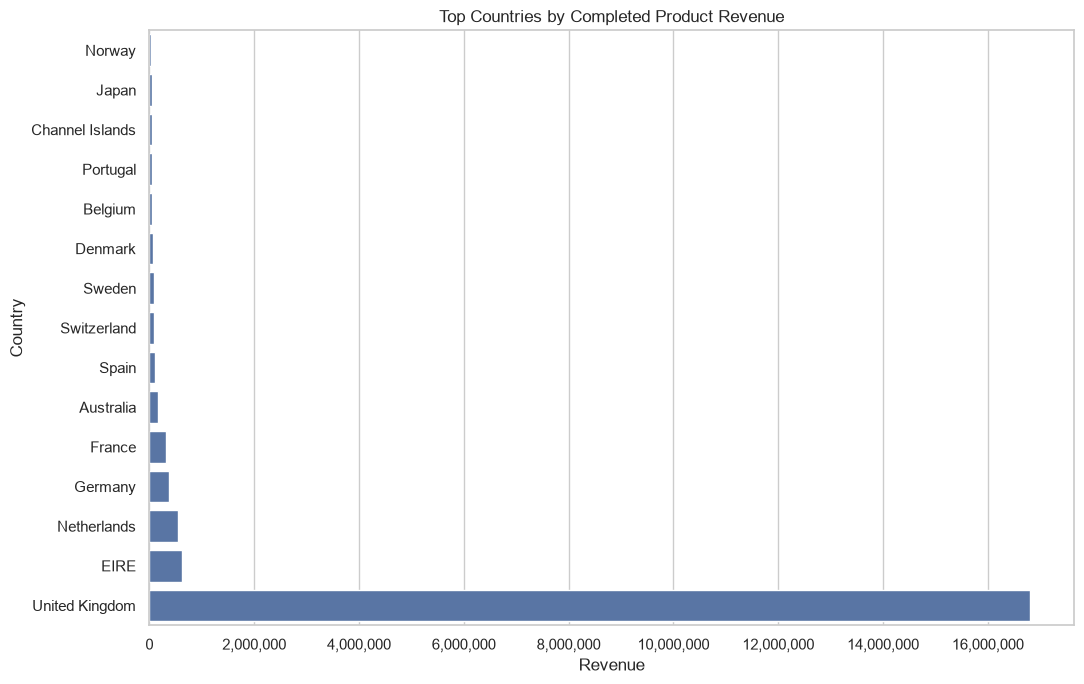

In [53]:
top_countries = (
    country_performance
    .head(15)
    .reset_index()
    .sort_values("Revenue")
)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=top_countries,
    x="Revenue",
    y="CountryAnalysis",
    ax=ax
)

ax.set_title("Top Countries by Completed Product Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Country")
ax.xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.tight_layout()


plt.savefig(
    figures_folder / "top_countries_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Analyse international markets separately

The United Kingdom will likely dominate the overall chart.

In [54]:
international_markets = (
    country_performance
    .drop(
        index="United Kingdom",
        errors="ignore"
    )
    .sort_values("Revenue", ascending=False)
)

international_markets.head(15)[
    [
        "Revenue",
        "RevenueSharePercent",
        "Orders",
        "Customers",
        "AverageOrderValue",
        "RevenueCancellationRatePercent"
    ]
]

,Revenue,RevenueSharePercent,Orders,Customers,AverageOrderValue,RevenueCancellationRatePercent
CountryAnalysis,,,,,,
EIRE,"623,414.16",3.17,581,3,"1,073.00",3.26
Netherlands,"549,773.41",2.80,216,22,"2,545.25",0.67
Germany,"383,289.00",1.95,753,107,509.02,2.27
France,"311,090.29",1.58,598,93,520.22,5.68
Australia,"167,800.01",0.85,89,15,"1,885.39",0.90
Spain,"97,766.75",0.50,144,38,678.94,13.25
Switzerland,"94,024.59",0.48,85,22,"1,106.17",1.18
Sweden,"86,319.14",0.44,99,19,871.91,2.29
Denmark,"67,422.69",0.34,42,12,"1,605.30",6.03


Plot the international markets performance

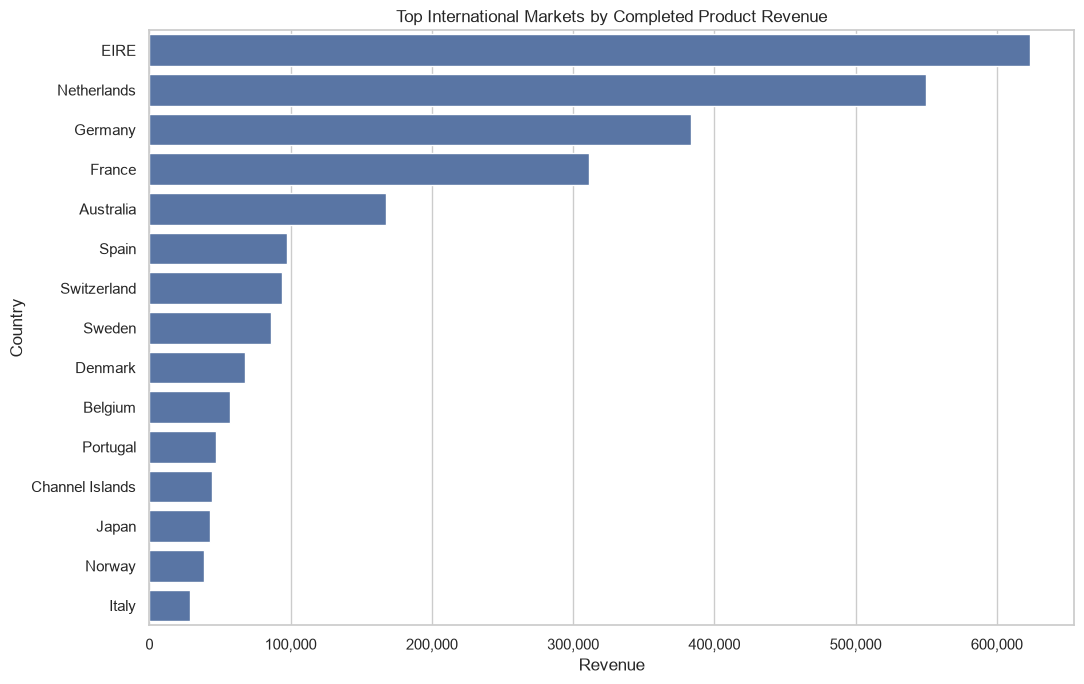

In [55]:
fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=international_markets.head(15).reset_index(),
    x="Revenue",
    y="CountryAnalysis",
    ax=ax
)

ax.set_title("Top International Markets by Completed Product Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Country")
ax.xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.tight_layout()

plt.savefig(
    figures_folder / "top_international_markets_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)




plt.show()

Find meaningful cancellation-risk markets

Exclude very small markets by requiring at least 20 sale invoices:

In [56]:
reliable_country_risk = (
    country_performance.loc[
        country_performance[
            "SaleInvoices"
        ] >= 20
    ]
)

reliable_country_risk.nlargest(
    10,
    "RevenueCancellationRatePercent"
)[
    [
        "Revenue",
        "SaleInvoices",
        "CancellationInvoices",
        "CancellationValue",
        "RevenueCancellationRatePercent",
        "UnitCancellationRatePercent"
    ]
]

,Revenue,SaleInvoices,CancellationInvoices,CancellationValue,RevenueCancellationRatePercent,UnitCancellationRatePercent
CountryAnalysis,,,,,,
Spain,"97,766.75",144,24,"12,955.19",13.25,11.28
Japan,"43,023.91",33,20,"3,277.14",7.62,4.74
Denmark,"67,422.69",42,8,"4,067.10",6.03,1.14
France,"311,090.29",598,111,"17,659.09",5.68,33.36
Channel Islands,"44,030.33",54,21,"2,188.52",4.97,4.70
United Kingdom,"16,802,912.41",36187,6646,"646,244.39",3.85,3.77
Poland,"10,214.29",28,10,374.36,3.67,3.24
EIRE,"623,414.16",581,146,"20,297.55",3.26,2.72
Italy,"28,937.50",59,21,710.70,2.46,1.21


Product performance and ABC analysis

Create product-level KPIs

In [57]:
description_lookup = (
    product_sales_df
    .dropna(subset=["Description"])
    .groupby(["StockCode", "Description"])
    .size()
    .reset_index(name="Rows")
    .sort_values(
        ["StockCode", "Rows"],
        ascending=[True, False]
    )
    .drop_duplicates("StockCode")
    .set_index("StockCode")["Description"]
)

In [58]:
product_performance = (
    product_sales_df
    .groupby("StockCode")
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique"),
        FirstSale=("InvoiceDate", "min"),
        LastSale=("InvoiceDate", "max"),
        ActiveMonths=(
            "InvoiceDate",
            lambda x: x.dt.to_period("M").nunique()
        )
    )
    .join(description_lookup)
)

product_performance["AverageSellingPrice"] = (
    product_performance["Revenue"]
    / product_performance[
        "UnitsSold"
    ].replace(0, np.nan)
)

product_performance["RevenueSharePercent"] = (
    product_performance["Revenue"]
    / product_performance["Revenue"].sum()
    * 100
)

product_performance = (
    product_performance
    .sort_values("Revenue", ascending=False)
)

Identify leading products



Top products by revenue:

In [59]:
Top_products_by_revenue = product_performance.head(15)[
    [
        "Description",
        "Revenue",
        "RevenueSharePercent",
        "UnitsSold",
        "Orders",
        "Customers",
        "AverageSellingPrice"
    ]
]

print("Top products by revenue:")
display(Top_products_by_revenue)

Top products by revenue:


,Description,Revenue,RevenueSharePercent,UnitsSold,Orders,Customers,AverageSellingPrice
StockCode,,,,,,,
22423,REGENCY CAKESTAND 3 TIER,"330,590.32",1.68,26478,3918,1314,12.49
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,724.71",1.31,94203,5365,1490,2.74
85099B,JUMBO BAG RED RETROSPOT,"180,569.34",0.92,96757,3989,978,1.87
23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",0.86,80995,1,1,2.08
47566,PARTY BUNTING,"148,318.28",0.75,28200,2674,894,5.26
84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",0.66,80082,2807,1010,1.61
22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",0.60,35084,2018,896,3.36
23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",0.42,78033,247,138,1.05
79321,CHILLI LIGHTS,"80,540.88",0.41,15841,1135,304,5.08


Top products by quantity:

In [60]:
Top_products_by_quantity = product_performance.nlargest(
    15,
    "UnitsSold"
)[
    [
        "Description",
        "UnitsSold",
        "Revenue",
        "Orders",
        "Customers",
        "AverageSellingPrice"
    ]
]

print("Top products by quantity sold:")
display(Top_products_by_quantity)

Top products by quantity sold:


,Description,UnitsSold,Revenue,Orders,Customers,AverageSellingPrice
StockCode,,,,,,
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139,"24,445.61",1019,482,0.23
85099B,JUMBO BAG RED RETROSPOT,96757,"180,569.34",3989,978,1.87
21212,PACK OF 72 RETROSPOT CAKE CASES,94884,"51,825.15",3118,1115,0.55
85123A,WHITE HANGING HEART T-LIGHT HOLDER,94203,"257,724.71",5365,1490,2.74
22197,SMALL POPCORN HOLDER,88499,"79,520.20",2322,601,0.90
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1,1,2.08
84879,ASSORTED COLOUR BIRD ORNAMENT,80082,"129,324.49",2807,1010,1.61
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",247,138,1.05
17003,BROCADE RING PURSE,70369,"14,766.42",456,215,0.21


Plot the top revenue products

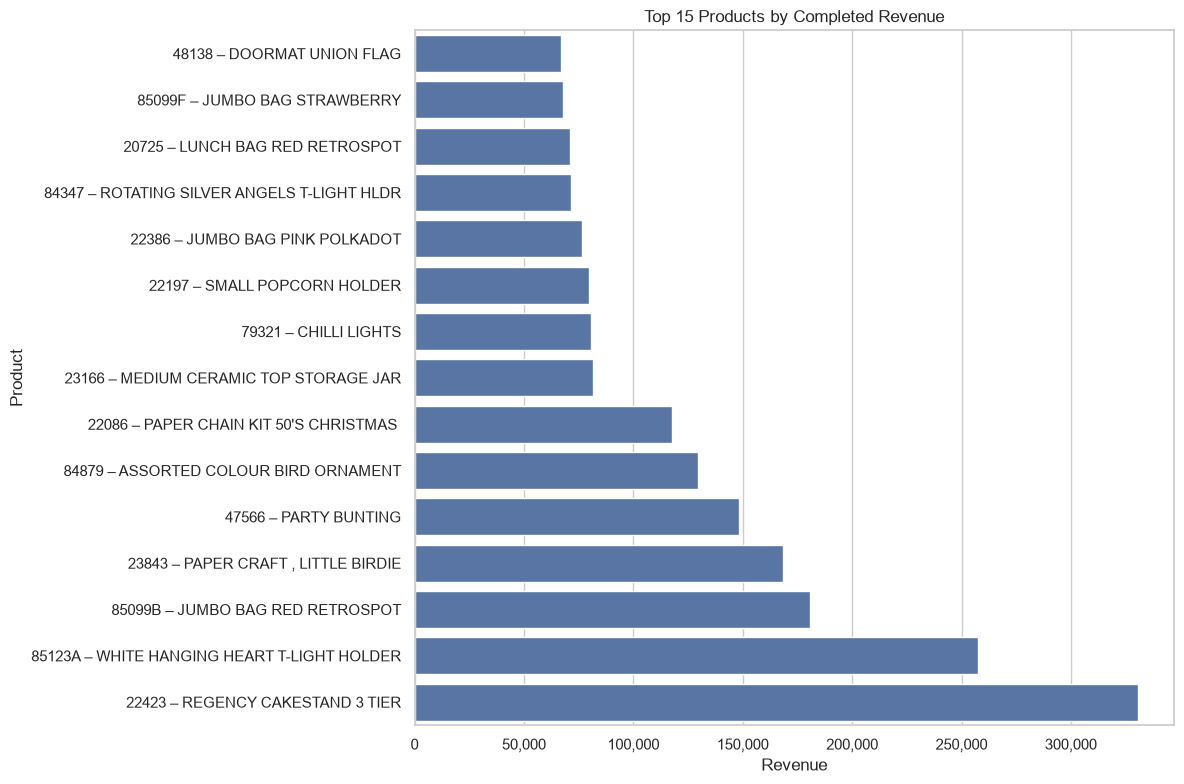

In [61]:
top_products = (
    product_performance
    .head(15)
    .reset_index()
)

top_products["ProductLabel"] = (
    top_products["StockCode"].astype(str)
    + " – "
    + top_products["Description"]
    .fillna("Missing description")
    .str.slice(0, 35)
)

top_products = top_products.sort_values("Revenue")

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=top_products,
    x="Revenue",
    y="ProductLabel",
    ax=ax
)

ax.set_title("Top 15 Products by Completed Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Product")
ax.xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.tight_layout()
plt.savefig(
    figures_folder / "top_products_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Create ABC classification for revenue generating products

ABC interpretation:

A: products producing approximately the first 80% of revenue.
B: products producing the next 15%.
C: products producing the remaining 5%.

In [62]:
product_performance[
    "CumulativeRevenuePercent"
] = (
    product_performance["Revenue"]
    .cumsum()
    / product_performance["Revenue"].sum()
    * 100
)

product_performance["PreviousCumulativePercent"] = (
    product_performance[
        "CumulativeRevenuePercent"
    ]
    - product_performance[
        "RevenueSharePercent"
    ]
)

product_performance["ABCClass"] = np.select(
    [
        product_performance[
            "PreviousCumulativePercent"
        ] < 80,

        product_performance[
            "PreviousCumulativePercent"
        ] < 95
    ],
    ["A", "B"],
    default="C"
)

In [63]:
abc_summary = (
    product_performance
    .groupby("ABCClass")
    .agg(
        Products=("Revenue", "size"),
        Revenue=("Revenue", "sum"),
        UnitsSold=("UnitsSold", "sum")
    )
    .reindex(["A", "B", "C"])
)

abc_summary["ProductSharePercent"] = (
    abc_summary["Products"]
    / abc_summary["Products"].sum()
    * 100
)

abc_summary["RevenueSharePercent"] = (
    abc_summary["Revenue"]
    / abc_summary["Revenue"].sum()
    * 100
)

abc_summary

,Products,Revenue,UnitsSold,ProductSharePercent,RevenueSharePercent
ABCClass,,,,,
A,1041,"15,720,749.95",7780957,21.23,80.02
B,1282,"2,943,445.96",2362277,26.14,14.98
C,2581,"981,558.75",1044910,52.63,5.00


Plot the Pareto curve

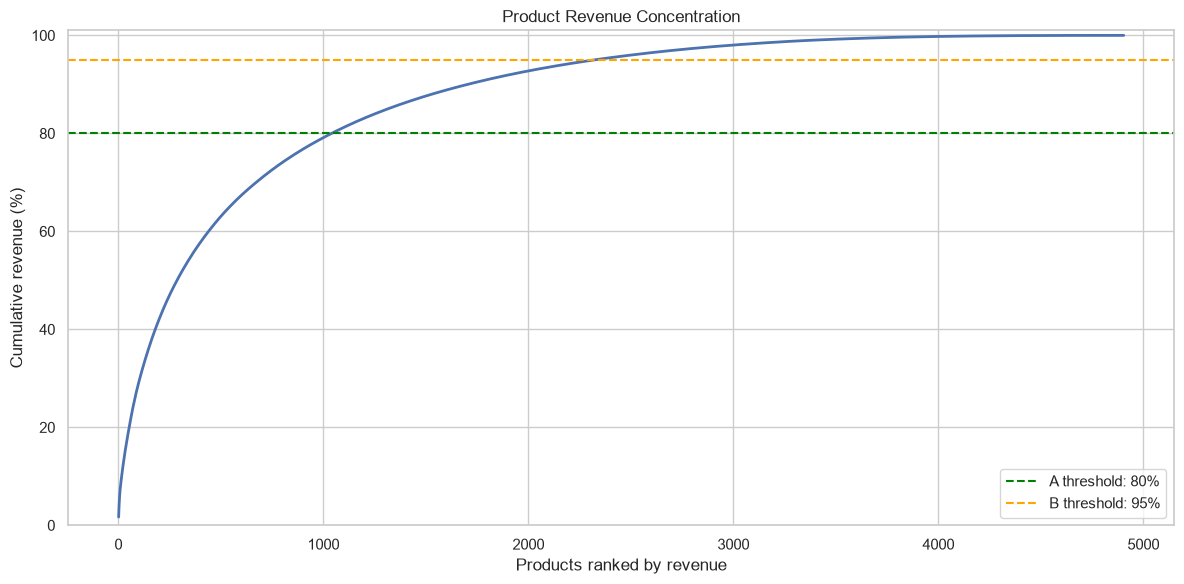

In [64]:
pareto_data = (
    product_performance
    .reset_index()
    .reset_index(names="ProductRank")
)

pareto_data["ProductRank"] += 1

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    pareto_data["ProductRank"],
    pareto_data["CumulativeRevenuePercent"],
    linewidth=2
)

ax.axhline(
    80,
    color="green",
    linestyle="--",
    label="A threshold: 80%"
)

ax.axhline(
    95,
    color="orange",
    linestyle="--",
    label="B threshold: 95%"
)

ax.set_title("Product Revenue Concentration")
ax.set_xlabel("Products ranked by revenue")
ax.set_ylabel("Cumulative revenue (%)")
ax.set_ylim(0, 101)
ax.legend()

plt.tight_layout()
plt.savefig(
    figures_folder / "products_revenue_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Measure product concentration

In [65]:
product_concentration = pd.Series({
    "Total products":
        len(product_performance),

    "Class A products":
        product_performance[
            "ABCClass"
        ].eq("A").sum(),

    "Class B products":
        product_performance[
            "ABCClass"
        ].eq("B").sum(),

    "Class C products":
        product_performance[
            "ABCClass"
        ].eq("C").sum(),

    "Top 10 products revenue share (%)":
        product_performance[
            "RevenueSharePercent"
        ].head(10).sum(),

    "Top 20 products revenue share (%)":
        product_performance[
            "RevenueSharePercent"
        ].head(20).sum()
})

product_concentration

Total products                      4,904.00
Class A products                    1,041.00
Class B products                    1,282.00
Class C products                    2,581.00
Top 10 products revenue share (%)       8.01
Top 20 products revenue share (%)      11.47
dtype: float64

Identify inactive or low-frequency products

In [66]:
last_observed_date = (
    product_sales_df["InvoiceDate"]
    .max()
    .normalize()
)

last_observed_month = (
    last_observed_date.to_period("M")
)

is_final_month_partial = (
    last_observed_date.day
    < last_observed_date.days_in_month
)

if is_final_month_partial:
    # First day of the partial month =
    # day after the last complete month
    lifecycle_reference_date = (
        last_observed_month.start_time
    )
else:
    lifecycle_reference_date = (
        last_observed_date
        + pd.Timedelta(days=1)
    )

print("Last observed date:", last_observed_date)
print(
    "Final month partial:",
    is_final_month_partial
)
print(
    "Lifecycle reference date:",
    lifecycle_reference_date
)

Last observed date: 2011-12-09 00:00:00
Final month partial: True
Lifecycle reference date: 2011-12-01 00:00:00


In [67]:
lifecycle_source = product_sales_df.loc[
    product_sales_df["InvoiceDate"]
    < lifecycle_reference_date
].copy()

if is_final_month_partial:
    partial_month_products = set(
        product_sales_df.loc[
            product_sales_df["InvoiceDate"]
            >= lifecycle_reference_date,
            "StockCodeNormalized"
        ]
    )
else:
    partial_month_products = set()

print(
    "Products sold in partial month:",
    len(partial_month_products)
)

Products sold in partial month: 2434


In [68]:
description_lookup = (
    product_sales_df
    .dropna(subset=["Description"])
    .groupby(
        [
            "StockCodeNormalized",
            "Description"
        ]
    )
    .size()
    .reset_index(name="Rows")
    .sort_values(
        ["StockCodeNormalized", "Rows"],
        ascending=[True, False]
    )
    .drop_duplicates(
        "StockCodeNormalized"
    )
    .set_index(
        "StockCodeNormalized"
    )["Description"]
)

In [69]:
product_lifecycle = (
    lifecycle_source
    .groupby("StockCodeNormalized")
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique"),
        FirstSale=("InvoiceDate", "min"),
        LastSale=("InvoiceDate", "max"),
        ActiveMonths=(
            "InvoiceDate",
            lambda x: x.dt.to_period(
                "M"
            ).nunique()
        )
    )
    .join(description_lookup)
)

In [70]:
product_lifecycle["DaysSinceLastSale"] = (
    lifecycle_reference_date
    - product_lifecycle[
        "LastSale"
    ].dt.normalize()
).dt.days

product_lifecycle["SalesHistoryDays"] = (
    product_lifecycle["LastSale"]
    - product_lifecycle["FirstSale"]
).dt.days

product_lifecycle["SoldInPartialMonth"] = (
    product_lifecycle.index.isin(
        partial_month_products
    )
)

In [71]:
product_lifecycle = (
    product_lifecycle
    .sort_values(
        "Revenue",
        ascending=False
    )
)

product_lifecycle["RevenueSharePercent"] = (
    product_lifecycle["Revenue"]
    / product_lifecycle["Revenue"].sum()
    * 100
)

product_lifecycle[
    "CumulativeRevenuePercent"
] = (
    product_lifecycle[
        "RevenueSharePercent"
    ].cumsum()
)

product_lifecycle[
    "PreviousCumulativePercent"
] = (
    product_lifecycle[
        "CumulativeRevenuePercent"
    ]
    - product_lifecycle[
        "RevenueSharePercent"
    ]
)

product_lifecycle["ABCClass"] = np.select(
    [
        product_lifecycle[
            "PreviousCumulativePercent"
        ] < 80,

        product_lifecycle[
            "PreviousCumulativePercent"
        ] < 95
    ],
    ["A", "B"],
    default="C"
)

In [72]:
INACTIVE_DAYS = 180
LOW_FREQUENCY_ORDERS = 5

product_lifecycle["IsLowFrequency"] = (
    product_lifecycle["Orders"]
    <= LOW_FREQUENCY_ORDERS
)

product_lifecycle["IsLongInactive"] = (
    product_lifecycle[
        "DaysSinceLastSale"
    ] > INACTIVE_DAYS
)

product_lifecycle["IsSeasonalProduct"] = (
    product_lifecycle["Description"]
    .str.contains(
        (
            r"CHRISTMAS|XMAS|ADVENT|"
            r"EASTER|VALENTINE|HALLOWEEN"
        ),
        case=False,
        regex=True,
        na=False
    )
)

In [73]:
product_lifecycle[
    "IsInactiveCandidate"
] = (
    product_lifecycle[
        "IsLongInactive"
    ]
    & product_lifecycle[
        "IsLowFrequency"
    ]
    & ~product_lifecycle[
        "SoldInPartialMonth"
    ]
)

In [74]:
product_lifecycle["LifecycleReview"] = np.select(
    [
        product_lifecycle[
            "SoldInPartialMonth"
        ],

        (
            product_lifecycle[
                "IsInactiveCandidate"
            ]
            & product_lifecycle[
                "IsSeasonalProduct"
            ]
        ),

        (
            product_lifecycle[
                "IsLongInactive"
            ]
            & product_lifecycle[
                "ABCClass"
            ].isin(["A", "B"])
        ),

        product_lifecycle[
            "IsInactiveCandidate"
        ],

        (
            product_lifecycle[
                "IsLowFrequency"
            ]
            & ~product_lifecycle[
                "IsLongInactive"
            ]
        )
    ],
    [
        "Active in partial final month",
        "Seasonal inactive candidate",
        "High-value inactive candidate",
        "Low-volume inactive candidate",
        "Low-frequency but recent"
    ],
    default="Active or established product"
)

In [75]:
inactive_product_candidates = (
    product_lifecycle.loc[
        product_lifecycle[
            "IsInactiveCandidate"
        ]
        |
        (
            product_lifecycle[
                "IsLongInactive"
            ]
            & product_lifecycle[
                "ABCClass"
            ].isin(["A", "B"])
        )
    ]
    .sort_values(
        [
            "DaysSinceLastSale",
            "Revenue"
        ],
        ascending=[False, False]
    )
)

inactive_product_candidates[
    [
        "Description",
        "Revenue",
        "UnitsSold",
        "Orders",
        "FirstSale",
        "LastSale",
        "DaysSinceLastSale",
        "SoldInPartialMonth",
        "ABCClass",
        "LifecycleReview"
    ]
].head(30)

,Description,Revenue,UnitsSold,Orders,FirstSale,LastSale,DaysSinceLastSale,SoldInPartialMonth,ABCClass,LifecycleReview
StockCodeNormalized,,,,,,,,,,
21767,FRENCH STYLE WIRE DOOR CABINET,29.95,1,1,2009-12-01 14:19:00,2009-12-01 14:19:00,730,False,C,Low-volume inactive candidate
84648,NEW BAROQUE WALL MIRROR,12.75,1,1,2009-12-01 13:07:00,2009-12-01 13:07:00,730,False,C,Low-volume inactive candidate
79070B,ENGLISH ROSE SQUARE CAKE TINS,11.26,1,1,2009-12-01 14:45:00,2009-12-01 14:45:00,730,False,C,Low-volume inactive candidate
20739,*USB Office Glitter Lamp,8.65,1,1,2009-12-01 14:28:00,2009-12-01 14:28:00,730,False,C,Low-volume inactive candidate
30086C,ASSORTED FRUIT STRAWS,1.70,1,1,2009-12-01 14:28:00,2009-12-01 14:28:00,730,False,C,Low-volume inactive candidate
21685,MEDINA STAMPED METAL TRAY,44.85,3,2,2009-12-01 14:59:00,2009-12-02 12:32:00,729,False,C,Low-volume inactive candidate
79065A,TEATIME ROUND CAKE TINS,39.80,4,1,2009-12-02 12:06:00,2009-12-02 12:06:00,729,False,C,Low-volume inactive candidate
35751C,PURPLE CURRENT CANDLE RING,12.61,31,2,2009-12-01 11:41:00,2009-12-02 16:24:00,729,False,C,Low-volume inactive candidate
84572,6 HOOK JEWEL STAND LILAC DRESS,8.49,1,1,2009-12-02 15:51:00,2009-12-02 15:51:00,729,False,C,Low-volume inactive candidate


Display recent low-frequency products separately

In [76]:
recent_low_frequency_products = (
    product_lifecycle.loc[
        product_lifecycle[
            "IsLowFrequency"
        ]
        & ~product_lifecycle[
            "IsLongInactive"
        ]
    ]
    .sort_values(
        ["Orders", "Revenue"],
        ascending=[True, True]
    )
)

recent_low_frequency_products[
    [
        "Description",
        "Revenue",
        "UnitsSold",
        "Orders",
        "FirstSale",
        "LastSale",
        "DaysSinceLastSale",
        "ABCClass",
        "LifecycleReview"
    ]
].head(30)

,Description,Revenue,UnitsSold,Orders,FirstSale,LastSale,DaysSinceLastSale,ABCClass,LifecycleReview
StockCodeNormalized,,,,,,,,,
23664,FLOWER SHOP DESIGN MUG,1.65,1,1,2011-11-11 15:28:00,2011-11-11 15:28:00,20,C,Low-frequency but recent
23609,SET 10 CARDS SNOWY ROBIN 17099,2.91,1,1,2011-11-28 15:31:00,2011-11-28 15:31:00,3,C,Low-frequency but recent
23628,SET 10 CARDS TRIANGLE ICONS 17220,2.91,1,1,2011-10-31 14:41:00,2011-10-31 14:41:00,31,C,Low-frequency but recent
23602,SET 10 CARDS 3 WISE MEN 17107,2.91,1,1,2011-11-11 13:06:00,2011-11-11 13:06:00,20,C,Low-frequency but recent
23643,SET 10 CARDS CHRISTMAS BAUBLE 16954,3.33,1,1,2011-10-31 14:41:00,2011-10-31 14:41:00,31,C,Low-frequency but recent
23617,SET 10 CARDS SWIRLY XMAS TREE 17104,5.82,2,1,2011-11-29 16:47:00,2011-11-29 16:47:00,2,C,Low-frequency but recent
23652,SET 10 CARD CHRISTMAS STAMPS 16963,5.82,2,1,2011-11-17 15:17:00,2011-11-17 15:17:00,14,C,Low-frequency but recent
20678,LARGE BLACK DIAMANTE HAIRSLIDE,6.60,4,1,2011-09-23 14:49:00,2011-09-23 14:49:00,69,C,Low-frequency but recent
23605,SET 10 CARDS 12 DAYS OF XMAS 17059,11.64,4,1,2011-10-05 15:56:00,2011-10-05 15:56:00,57,C,Low-frequency but recent


One-time vs repeat customers

Prepare customer sales

In [77]:
repeat_source = customer_sales_df.copy()

repeat_source = repeat_source[
    repeat_source["CustomerID"].notna()
].copy()

repeat_source["CustomerID"] = (
    repeat_source["CustomerID"]
    .astype("Int64")
)

In [78]:
customer_order_summary = (
    customer_sales_df
    .groupby("CustomerID")
    .agg(
        Orders=("Invoice", "nunique"),
        Revenue=("Revenue", "sum"),
        UnitsPurchased=("Quantity", "sum"),
        UniqueProducts=("StockCodeNormalized", "nunique"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_order_summary["CustomerType"] = np.where(
    customer_order_summary["Orders"].eq(1),
    "One-time Customer",
    "Repeat Customer"
)

customer_order_summary.head()

,CustomerID,Orders,Revenue,UnitsPurchased,UniqueProducts,FirstPurchase,LastPurchase,CustomerType
0,12346,3,"77,352.96",74239,25,2010-03-02 13:08:00,2011-01-18 10:01:00,Repeat Customer
1,12347,8,"4,921.53",2967,126,2010-10-31 14:20:00,2011-12-07 15:52:00,Repeat Customer
2,12348,5,"1,658.40",2704,24,2010-09-27 14:59:00,2011-09-25 13:13:00,Repeat Customer
3,12349,3,"3,678.69",1621,137,2010-04-29 13:20:00,2011-11-21 09:51:00,Repeat Customer
4,12350,1,294.40,196,16,2011-02-02 16:01:00,2011-02-02 16:01:00,One-time Customer


In [79]:
customer_type_summary = (
    customer_order_summary
    .groupby("CustomerType")
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalRevenue=("Revenue", "sum"),
        AverageRevenuePerCustomer=("Revenue", "mean"),
        MedianRevenuePerCustomer=("Revenue", "median"),
        AverageOrdersPerCustomer=("Orders", "mean"),
        AverageUnitsPerCustomer=("UnitsPurchased", "mean"),
        AverageUniqueProducts=("UniqueProducts", "mean")
    )
    .reset_index()
)

customer_type_summary["CustomerSharePercent"] = (
    customer_type_summary["Customers"]
    / customer_type_summary["Customers"].sum()
    * 100
)

customer_type_summary["RevenueSharePercent"] = (
    customer_type_summary["TotalRevenue"]
    / customer_type_summary["TotalRevenue"].sum()
    * 100
)

customer_type_summary.round(2)

,CustomerType,Customers,TotalRevenue,AverageRevenuePerCustomer,MedianRevenuePerCustomer,AverageOrdersPerCustomer,AverageUnitsPerCustomer,AverageUniqueProducts,CustomerSharePercent,RevenueSharePercent
0,One-time Customer,1618,"555,999.97",343.63,228.94,1.00,264.48,21.18,27.65,3.26
1,Repeat Customer,4234,"16,512,582.76","3,900.00","1,364.12",8.26,"2,378.56",105.51,72.35,96.74


In [80]:
assert (
    customer_order_summary.loc[
        customer_order_summary["CustomerType"].eq(
            "One-time Customer"
        ),
        "Orders"
    ] == 1
).all()

assert (
    customer_order_summary.loc[
        customer_order_summary["CustomerType"].eq(
            "Repeat Customer"
        ),
        "Orders"
    ] > 1
).all()

assert (
    customer_order_summary["Customers"]
    if "Customers" in customer_order_summary.columns
    else customer_order_summary["CustomerID"]
).notna().all()

print("Customer classification validation passed.")
print(
    "Customers classified:",
    customer_order_summary["CustomerID"].nunique()
)

Customer classification validation passed.
Customers classified: 5852


In [81]:
total_customers = customer_order_summary["CustomerID"].nunique()

repeat_customers = (
    customer_order_summary["CustomerType"]
    .eq("Repeat Customer")
    .sum()
)

one_time_customers = (
    customer_order_summary["CustomerType"]
    .eq("One-time Customer")
    .sum()
)

repeat_customer_share = (
    repeat_customers / total_customers * 100
)

repeat_revenue_share = customer_type_summary.loc[
    customer_type_summary["CustomerType"].eq(
        "Repeat Customer"
    ),
    "RevenueSharePercent"
].iloc[0]

print(f"Total customers: {total_customers:,}")
print(f"One-time customers: {one_time_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(
    f"Repeat-customer share: "
    f"{repeat_customer_share:.2f}%"
)
print(
    f"Repeat-customer revenue share: "
    f"{repeat_revenue_share:.2f}%"
)

Total customers: 5,852
One-time customers: 1,618
Repeat customers: 4,234
Repeat-customer share: 72.35%
Repeat-customer revenue share: 96.74%


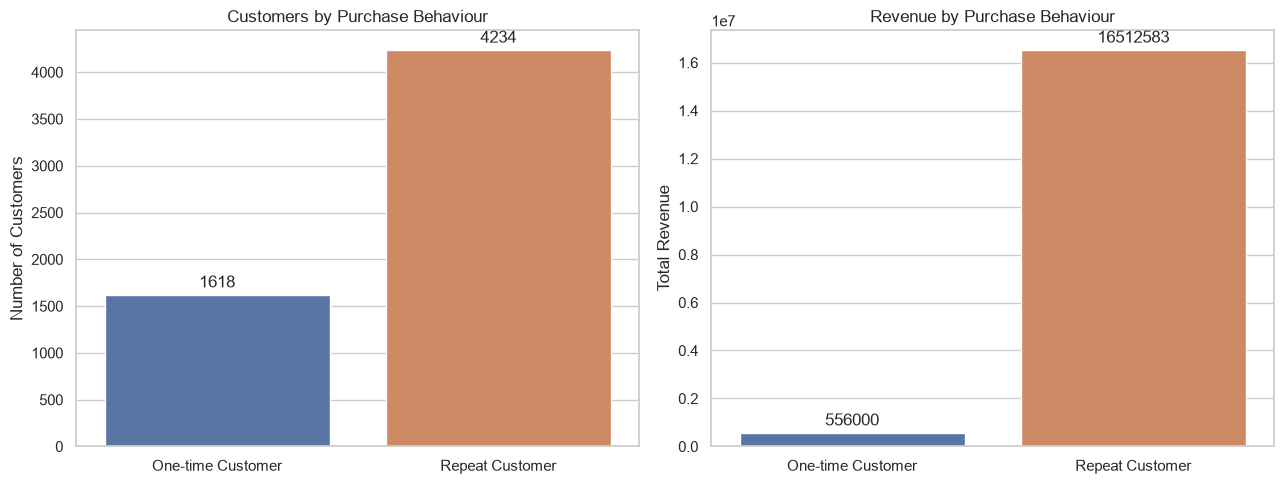

In [82]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

customer_order = [
    "One-time Customer",
    "Repeat Customer"
]

plot_data = (
    customer_type_summary
    .set_index("CustomerType")
    .reindex(customer_order)
    .reset_index()
)

sns.barplot(
    data=plot_data,
    x="CustomerType",
    y="Customers",
    hue="CustomerType",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Customers by Purchase Behaviour")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Customers")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

sns.barplot(
    data=plot_data,
    x="CustomerType",
    y="TotalRevenue",
    hue="CustomerType",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Revenue by Purchase Behaviour")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Revenue")

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()
plt.savefig(
    figures_folder / "customer_behavior.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [83]:
customer_type_summary[
    [
        "CustomerType",
        "Customers",
        "CustomerSharePercent",
        "TotalRevenue",
        "RevenueSharePercent",
        "AverageOrdersPerCustomer",
        "AverageRevenuePerCustomer",
        "AverageUnitsPerCustomer"
    ]
].round(2)

,CustomerType,Customers,CustomerSharePercent,TotalRevenue,RevenueSharePercent,AverageOrdersPerCustomer,AverageRevenuePerCustomer,AverageUnitsPerCustomer
0,One-time Customer,1618,27.65,"555,999.97",3.26,1.00,343.63,264.48
1,Repeat Customer,4234,72.35,"16,512,582.76",96.74,8.26,"3,900.00","2,378.56"


### One-time vs Repeat Customer Findings

- Repeat customers represent __% of identified customers.
- Repeat customers generate __% of completed-sales revenue.
- Repeat customers place an average of __ orders.
- One-time customers represent __% of identified customers.
- The difference between customer share and revenue share indicates
  the commercial importance of repeat purchasing.

In [84]:
last_observed_date = (
    product_sales_df["InvoiceDate"]
    .max()
    .normalize()
)

expected_month_end = (
    last_observed_date
    + pd.offsets.MonthEnd(0)
).normalize()

if last_observed_date < expected_month_end:
    final_month_start = last_observed_date.replace(day=1)

    time_pattern_df = product_sales_df.loc[
        product_sales_df["InvoiceDate"]
        < final_month_start
    ].copy()

    print(
        "Excluded incomplete final month:",
        final_month_start.strftime("%B %Y")
    )
else:
    time_pattern_df = product_sales_df.copy()

print("Rows used:", len(time_pattern_df))
print(
    "Analysis period:",
    time_pattern_df["InvoiceDate"].min(),
    "to",
    time_pattern_df["InvoiceDate"].max()
)

Excluded incomplete final month: December 2011
Rows used: 978683
Analysis period: 2009-12-01 07:45:00 to 2011-11-30 17:37:00


In [85]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

time_pattern_df["Weekday"] = pd.Categorical(
    time_pattern_df["InvoiceDate"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

time_pattern_df["Hour"] = (
    time_pattern_df["InvoiceDate"].dt.hour
)

In [86]:
weekday_summary = (
    time_pattern_df
    .groupby("Weekday", observed=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        UnitsSold=("Quantity", "sum"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

weekday_summary["AverageOrderValue"] = np.where(
    weekday_summary["Orders"] > 0,
    weekday_summary["Revenue"]
    / weekday_summary["Orders"],
    np.nan
)

weekday_summary["RevenueSharePercent"] = (
    weekday_summary["Revenue"]
    / weekday_summary["Revenue"].sum()
    * 100
)

weekday_summary.round(2)

,Weekday,Revenue,Orders,UnitsSold,Customers,AverageOrderValue,RevenueSharePercent
0,Monday,"3,337,114.10",6120,1983902,2501,545.28,17.53
1,Tuesday,"3,825,164.10",7033,2108447,2688,543.89,20.10
2,Wednesday,"3,302,816.79",7011,1954644,2725,471.09,17.35
3,Thursday,"3,882,368.60",7926,2255368,2932,489.83,20.40
4,Friday,"2,913,058.12",5825,1554029,2385,500.10,15.31
5,Saturday,"9,803.05",30,5119,26,326.77,0.05
6,Sunday,"1,760,930.64",4758,1013987,2111,370.10,9.25


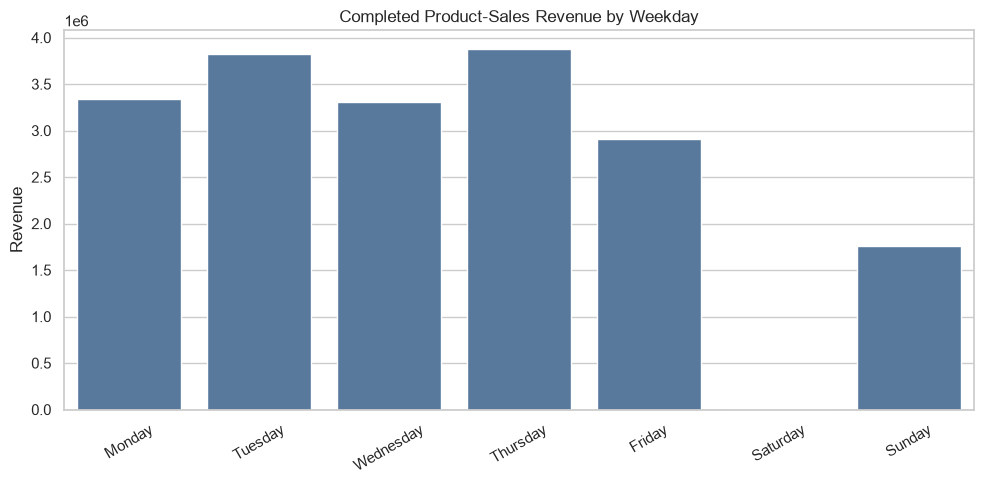

In [87]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_summary,
    x="Weekday",
    y="Revenue",
    color="#4C78A8"
)

plt.title("Completed Product-Sales Revenue by Weekday")
plt.xlabel("")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(
    figures_folder / "weekday_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [88]:
hourly_summary = (
    time_pattern_df
    .groupby("Hour")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        UnitsSold=("Quantity", "sum"),
        Customers=("CustomerID", "nunique")
    )
    .reindex(range(24), fill_value=0)
    .reset_index()
)

hourly_summary["AverageOrderValue"] = np.where(
    hourly_summary["Orders"] > 0,
    hourly_summary["Revenue"]
    / hourly_summary["Orders"],
    np.nan
)

hourly_summary.round(2)

,Hour,Revenue,Orders,UnitsSold,Customers,AverageOrderValue
0,0,0.00,0,0,0,NaN
1,1,0.00,0,0,0,NaN
2,2,0.00,0,0,0,NaN
3,3,0.00,0,0,0,NaN
4,4,0.00,0,0,0,NaN
5,5,0.00,0,0,0,NaN
6,6,4.25,1,1,1,4.25
7,7,"75,029.57",76,44857,67,987.23
8,8,"508,865.33",967,287773,674,526.23
9,9,"1,503,553.51",2665,819549,1368,564.19


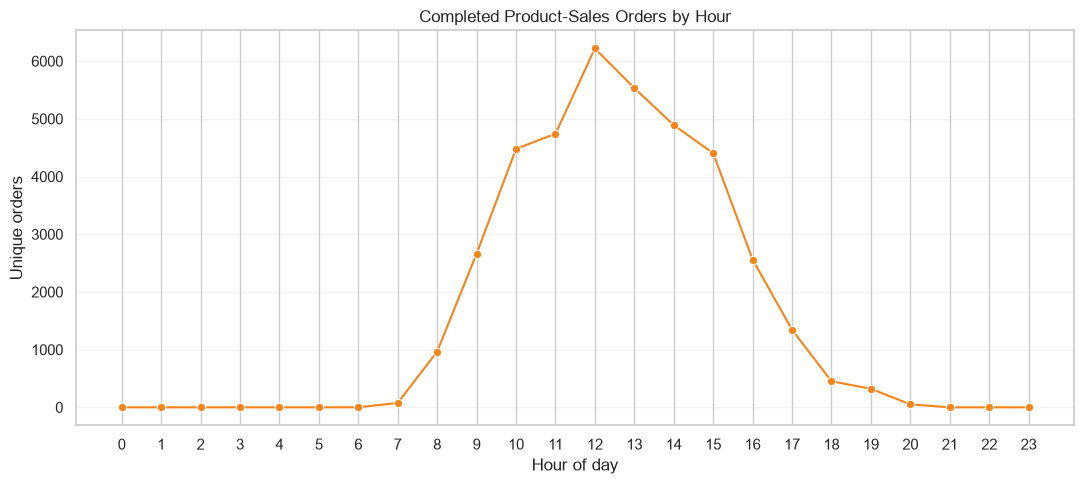

In [89]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=hourly_summary,
    x="Hour",
    y="Orders",
    marker="o",
    color="#F58518"
)

plt.title("Completed Product-Sales Orders by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Unique orders")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    figures_folder / "hourly_sales_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
peak_revenue_weekday = weekday_summary.loc[
    weekday_summary["Revenue"].idxmax()
]

peak_order_weekday = weekday_summary.loc[
    weekday_summary["Orders"].idxmax()
]

peak_revenue_hour = hourly_summary.loc[
    hourly_summary["Revenue"].idxmax()
]

peak_order_hour = hourly_summary.loc[
    hourly_summary["Orders"].idxmax()
]

print(
    "Highest-revenue weekday:",
    peak_revenue_weekday["Weekday"]
)

print(
    "Highest-order weekday:",
    peak_order_weekday["Weekday"]
)

print(
    "Highest-revenue hour:",
    int(peak_revenue_hour["Hour"])
)

print(
    "Highest-order hour:",
    int(peak_order_hour["Hour"])
)

Highest-revenue weekday: Thursday
Highest-order weekday: Thursday
Highest-revenue hour: 12
Highest-order hour: 12


Customer cohort and retention analysis

In [91]:
last_observed_date = customer_sales_df[
    "InvoiceDate"
].max()

last_observed_month = (
    last_observed_date.to_period("M")
)

if last_observed_date.day < last_observed_date.days_in_month:
    last_complete_month = last_observed_month - 1
else:
    last_complete_month = last_observed_month

print("Last observed month:", last_observed_month)
print("Last complete month:", last_complete_month)

Last observed month: 2011-12
Last complete month: 2011-11


In [92]:
cohort_data = customer_sales_df.loc[
    customer_sales_df["InvoiceDate"]
    .dt.to_period("M")
    <= last_complete_month
].copy()

Assign customers to acquisition cohorts

In [93]:
cohort_data["TransactionMonth"] = (
    cohort_data["InvoiceDate"].dt.to_period("M")
)

cohort_data["CohortMonth"] = (
    cohort_data
    .groupby("CustomerID")[
        "TransactionMonth"
    ]
    .transform("min")
)

cohort_data["CohortIndex"] = (
    (
        cohort_data["TransactionMonth"].dt.year
        - cohort_data["CohortMonth"].dt.year
    ) * 12
    +
    (
        cohort_data["TransactionMonth"].dt.month
        - cohort_data["CohortMonth"].dt.month
    )
    
).astype(int)


cohort_data[
    [
        "CustomerID",
        "InvoiceDate",
        "TransactionMonth",
        "CohortMonth",
        "CohortIndex"
    ]
].head()

,CustomerID,InvoiceDate,TransactionMonth,CohortMonth,CohortIndex
0,13085,2009-12-01 07:45:00,2009-12,2009-12,0
1,13085,2009-12-01 07:45:00,2009-12,2009-12,0
2,13085,2009-12-01 07:45:00,2009-12,2009-12,0
3,13085,2009-12-01 07:45:00,2009-12,2009-12,0
4,13085,2009-12-01 07:45:00,2009-12,2009-12,0


In [94]:
print(
    "Minimum CohortIndex:",
    cohort_data["CohortIndex"].min()
)

print(
    "Maximum CohortIndex:",
    cohort_data["CohortIndex"].max()
)

assert cohort_data["CohortIndex"].min() == 0

Minimum CohortIndex: 0
Maximum CohortIndex: 23


Count unique active customers by cohort and month

In [95]:
cohort_counts_raw = (
    cohort_data
    .groupby(
        ["CohortMonth", "CohortIndex"],
        observed=True
    )["CustomerID"]
    .nunique()
    .unstack()
)

max_cohort_index = int(
    cohort_data["CohortIndex"].max()
)

cohort_counts = cohort_counts_raw.reindex(
    columns=range(max_cohort_index + 1)
)

In [96]:
# cohort_data should already exclude the incomplete final month
last_complete_month = (
    cohort_data["TransactionMonth"].max()
)

for cohort_month in cohort_counts.index:

    observable_months = (
        (
            last_complete_month.year
            - cohort_month.year
        ) * 12
        +
        (
            last_complete_month.month
            - cohort_month.month
        )
    )

    eligible_columns = [
        column
        for column in cohort_counts.columns
        if column <= observable_months
    ]

    future_columns = [
        column
        for column in cohort_counts.columns
        if column > observable_months
    ]

    # No purchases in an observable month means zero retention
    cohort_counts.loc[
        cohort_month,
        eligible_columns
    ] = (
        cohort_counts.loc[
            cohort_month,
            eligible_columns
        ].fillna(0)
    )

    # Future months are not yet observable
    cohort_counts.loc[
        cohort_month,
        future_columns
    ] = np.nan

Calculate retention percentages:

In [97]:
# Month 0 is the cohort's acquisition-month customer count
cohort_sizes = cohort_counts[0]

retention_table = (
    cohort_counts
    .div(cohort_sizes, axis=0)
    .mul(100)
)

assert np.allclose(
    retention_table[0].dropna(),
    100
)

print(
    "Cohort index range:",
    retention_table.columns.min(),
    "to",
    retention_table.columns.max()
)

retention_table.loc[:, 0:12].round(1)

Cohort index range: 0 to 23


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12,100.00,35.00,33.30,42.50,37.90,36.00,37.60,34.40,33.80,36.20,42.20,49.60,37.60
2010-01,100.00,21.50,32.10,31.50,27.20,31.00,26.90,23.40,28.50,32.60,31.00,17.90,22.80
2010-02,100.00,23.50,22.70,29.30,24.50,19.70,19.20,28.80,25.60,27.70,11.50,12.50,15.20
2010-03,100.00,19.00,23.10,24.30,23.10,20.40,24.70,30.60,27.70,10.90,11.60,14.50,20.00
2010-04,100.00,19.00,19.00,16.00,18.40,22.10,27.60,26.50,10.50,10.90,7.50,13.90,14.30
2010-05,100.00,15.70,16.90,17.60,17.60,25.50,21.20,12.50,5.90,8.20,11.40,13.30,15.30
2010-06,100.00,17.60,18.70,20.60,23.20,28.50,12.70,9.00,8.20,11.20,10.50,13.90,15.00
2010-07,100.00,15.70,18.40,29.70,29.20,14.10,11.40,14.60,14.60,11.40,13.50,14.60,13.00
2010-08,100.00,19.60,28.80,32.50,16.60,11.70,9.80,12.90,13.50,12.90,12.90,11.70,14.70


Plot the first-year retention heatmap

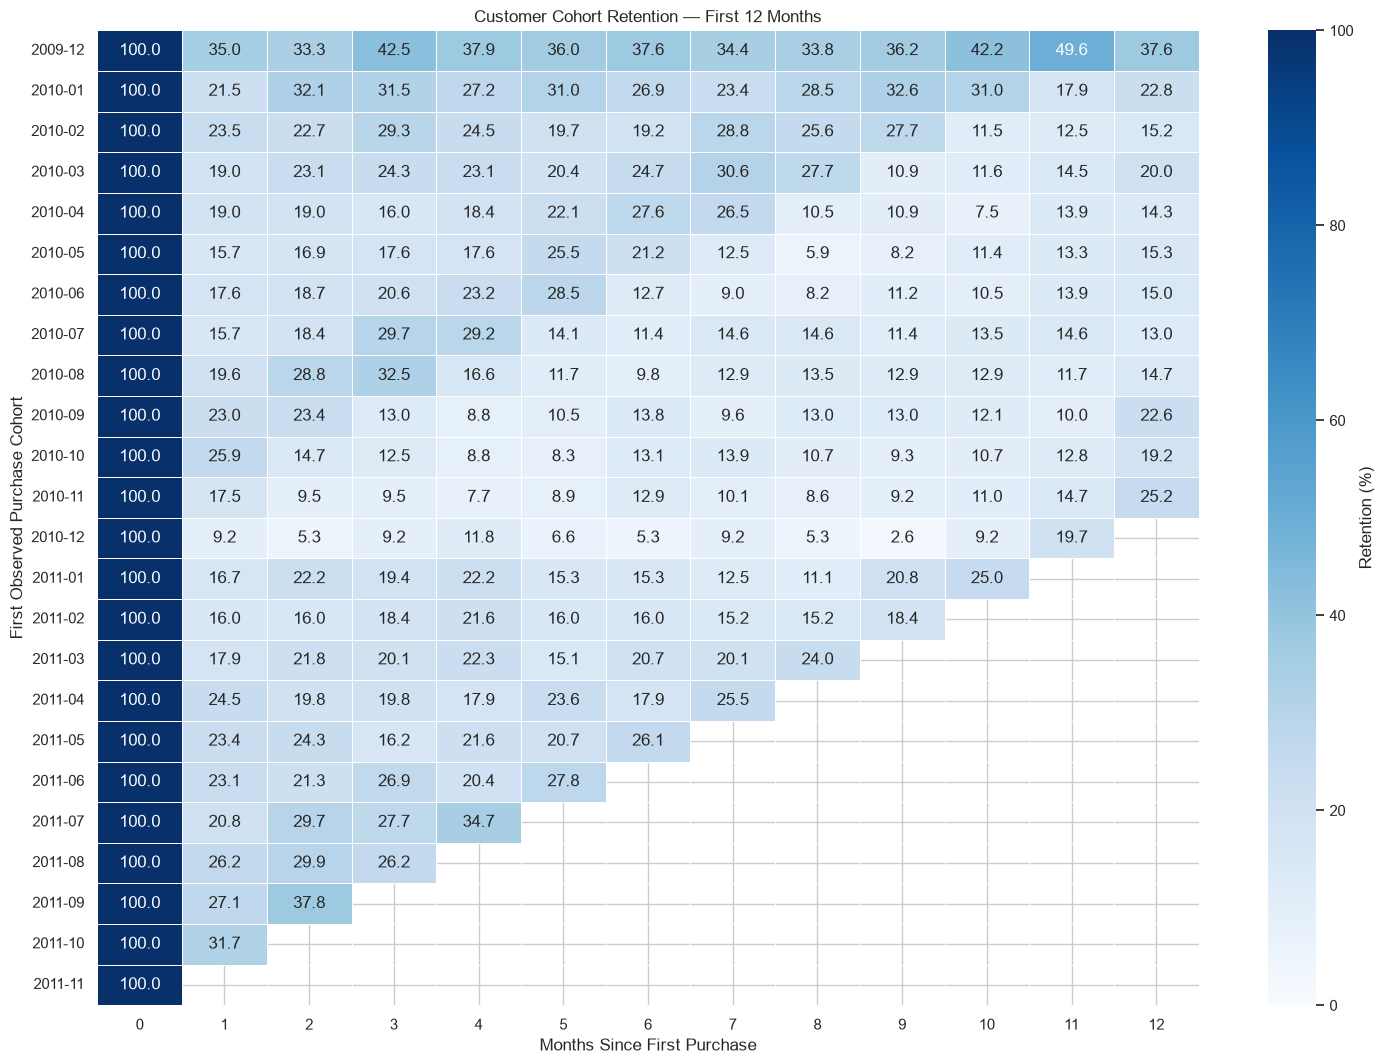

In [98]:
# Month 0 plus Months 1–12 = 13 displayed columns
first_year_retention = (
    retention_table
    .reindex(columns=range(13))
)

plt.figure(
    figsize=(
        15,
        max(8, len(first_year_retention) * 0.45)
    )
)

sns.heatmap(
    first_year_retention,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    mask=first_year_retention.isna(),
    linewidths=0.4,
    cbar_kws={"label": "Retention (%)"}
)

plt.title(
    "Customer Cohort Retention — First 12 Months"
)
plt.xlabel("Months Since First Purchase")
plt.ylabel("First Observed Purchase Cohort")
plt.tight_layout()
plt.savefig(
    figures_folder / "cohort_retention_first_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [99]:
assert retention_table.columns.max() >= 23

retention_23_months = (
    retention_table
    .reindex(columns=range(24))
)

print(
    "Displayed months:",
    retention_23_months.columns.min(),
    "to",
    retention_23_months.columns.max()
)

Displayed months: 0 to 23


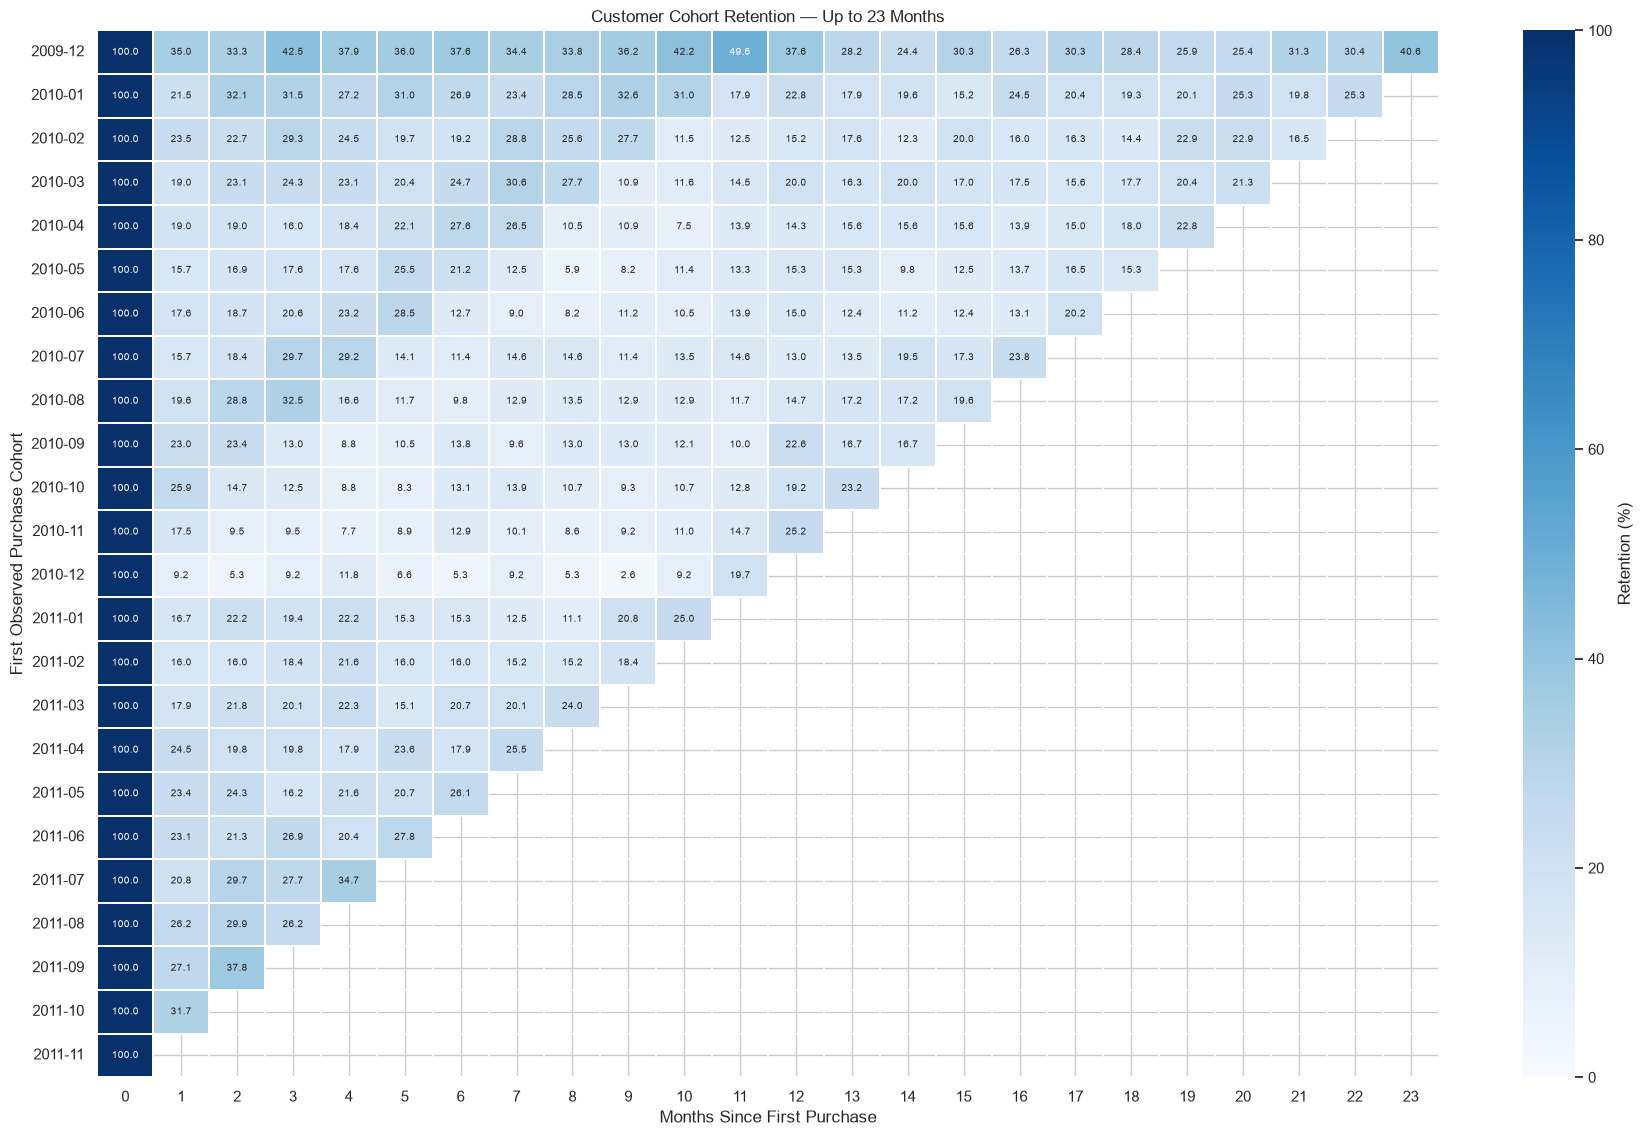

In [100]:
plt.figure(
    figsize=(
        18,
        max(9, len(retention_23_months) * 0.48)
    )
)

sns.heatmap(
    retention_23_months,
    annot=True,
    fmt=".1f",
    annot_kws={"fontsize": 7},
    cmap="Blues",
    vmin=0,
    vmax=100,
    mask=retention_23_months.isna(),
    linewidths=0.3,
    cbar_kws={"label": "Retention (%)"}
)

plt.title(
    "Customer Cohort Retention — Up to 23 Months"
)
plt.xlabel("Months Since First Purchase")
plt.ylabel("First Observed Purchase Cohort")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    figures_folder / "cohort_retention_23_months.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [101]:
retention_support = pd.DataFrame({
    "Month": retention_23_months.columns,
    "EligibleCohorts": (
        retention_23_months.notna().sum().values
    )
})

retention_support

,Month,EligibleCohorts
0,0,24
1,1,23
2,2,22
3,3,21
4,4,20
5,5,19
6,6,18
7,7,17
8,8,16
9,9,15


Calculate weighted retention

In [102]:
weighted_retention_rows = []

for cohort_index in cohort_counts.columns:

    eligible_mask = (
        cohort_counts[cohort_index].notna()
    )

    eligible_customers = (
        cohort_sizes.loc[eligible_mask].sum()
    )

    active_customers = (
        cohort_counts.loc[
            eligible_mask,
            cohort_index
        ].sum()
    )

    weighted_retention_rows.append({
        "CohortIndex": cohort_index,
        "CohortsObserved": eligible_mask.sum(),
        "EligibleCustomers": eligible_customers,
        "ActiveCustomers": active_customers,
        "WeightedRetentionPercent": (
            active_customers
            / eligible_customers
            * 100
            if eligible_customers > 0
            else np.nan
        )
    })

weighted_retention = pd.DataFrame(
    weighted_retention_rows
).set_index("CohortIndex")

weighted_retention.head(12)

,CohortsObserved,EligibleCustomers,ActiveCustomers,WeightedRetentionPercent
CohortIndex,,,,
0,24,"5,824.00","5,824.00",100.00
1,23,"5,633.00","1,315.00",23.34
2,22,"5,412.00","1,277.00",23.60
3,21,"5,224.00","1,305.00",24.98
4,20,"5,117.00","1,167.00",22.81
5,19,"5,016.00","1,097.00",21.87
6,18,"4,908.00","1,088.00",22.17
7,17,"4,797.00","1,044.00",21.76
8,16,"4,691.00",934.00,19.91


Create headline retention KPIs:

In [103]:
def get_retention(month_number):
    if month_number in weighted_retention.index:
        return weighted_retention.loc[
            month_number,
            "WeightedRetentionPercent"
        ]
    return np.nan

In [104]:
retention_kpis = pd.Series({
    "Month 1 retention (%)":
        get_retention(1),

    "Month 2 retention (%)":
        get_retention(2),

    "Month 3 retention (%)":
        get_retention(3),

    "Month 6 retention (%)":
        get_retention(6),

    "Month 12 retention (%)":
        get_retention(12)
})

retention_kpis

Month 1 retention (%)    23.34
Month 2 retention (%)    23.60
Month 3 retention (%)    24.98
Month 6 retention (%)    22.17
Month 12 retention (%)   22.74
dtype: float64

Validating the retention rates

In [105]:
checkpoint_months = [1, 2, 3, 6, 12]

retention_validation = []

for month_number in checkpoint_months:
    eligible_mask = (
        cohort_counts[month_number].notna()
    )

    retained_customers = cohort_counts.loc[
        eligible_mask,
        month_number
    ].sum()

    eligible_customers = cohort_counts.loc[
        eligible_mask,
        0
    ].sum()

    retention_validation.append({
        "Month": month_number,
        "RetainedCustomers": int(
            retained_customers
        ),
        "EligibleCustomers": int(
            eligible_customers
        ),
        "EligibleCohorts": int(
            eligible_mask.sum()
        ),
        "RetentionPercent": (
            retained_customers
            / eligible_customers
            * 100
        )
    })

retention_validation = pd.DataFrame(
    retention_validation
)

retention_validation.round(2)

,Month,RetainedCustomers,EligibleCustomers,EligibleCohorts,RetentionPercent
0,1,1315,5633,23,23.34
1,2,1277,5412,22,23.60
2,3,1305,5224,21,24.98
3,6,1088,4908,18,22.17
4,12,964,4239,12,22.74


In [106]:
assert np.allclose(
    retention_table[0].dropna(),
    100
)

assert retention_table.columns.min() == 0
assert retention_table.columns.max() == 23

print("Retention calculation is valid.")

Retention calculation is valid.


Approximately 23% of customers returned in the month following their first observed purchase. Monthly active retention remained relatively stable at around 22–25% through Month 12, although later-month estimates are based on fewer eligible cohorts.

In [107]:
overall_retention_records = []

for month_number in sorted(
    cohort_counts.columns
):
    eligible_mask = (
        cohort_counts[month_number].notna()
    )

    retained_customers = cohort_counts.loc[
        eligible_mask,
        month_number
    ].sum()

    eligible_customers = cohort_counts.loc[
        eligible_mask,
        0
    ].sum()

    retention_rate = (
        retained_customers
        / eligible_customers
        * 100
    )

    overall_retention_records.append({
        "Month": int(month_number),
        "RetentionRatePercent": retention_rate,
        "RetainedCustomers": int(
            retained_customers
        ),
        "EligibleCustomers": int(
            eligible_customers
        ),
        "EligibleCohorts": int(
            eligible_mask.sum()
        )
    })

overall_retention = pd.DataFrame(
    overall_retention_records
)

overall_retention.round(2)

,Month,RetentionRatePercent,RetainedCustomers,EligibleCustomers,EligibleCohorts
0,0,100.00,5824,5824,24
1,1,23.34,1315,5633,23
2,2,23.60,1277,5412,22
3,3,24.98,1305,5224,21
4,4,22.81,1167,5117,20
5,5,21.87,1097,5016,19
6,6,22.17,1088,4908,18
7,7,21.76,1044,4797,17
8,8,19.91,934,4691,16
9,9,19.44,877,4512,15


In [108]:
assert not overall_retention.empty

assert overall_retention[
    "Month"
].min() == 0

assert np.isclose(
    overall_retention.loc[
        overall_retention["Month"].eq(0),
        "RetentionRatePercent"
    ].iloc[0],
    100
)

print("Overall retention table created.")

Overall retention table created.


Analyse new-customer acquisition

In [109]:
new_customers_by_month = (
    cohort_sizes
    .rename("NewCustomers")
    .to_frame()
)

new_customers_by_month.tail(12)

,NewCustomers
CohortMonth,
2010-12,76.00
2011-01,72.00
2011-02,125.00
2011-03,179.00
2011-04,106.00
2011-05,111.00
2011-06,108.00
2011-07,101.00
2011-08,107.00


Plot New Customers

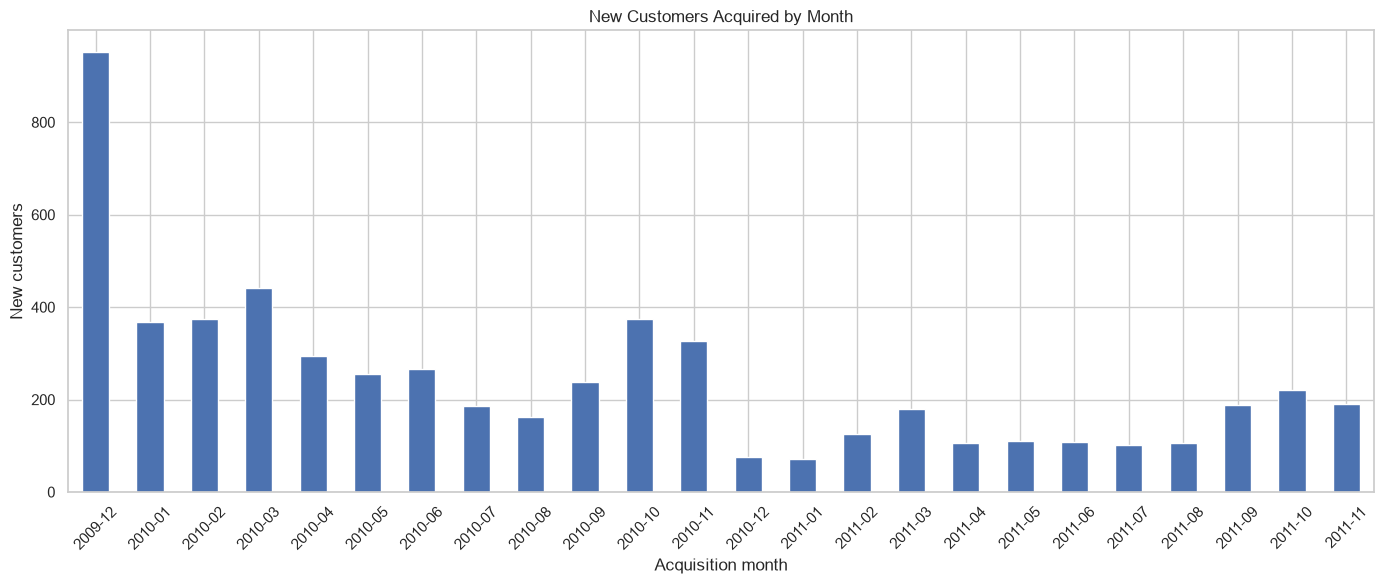

In [110]:
fig, ax = plt.subplots(figsize=(14, 6))

new_customers_by_month.plot(
    kind="bar",
    y="NewCustomers",
    legend=False,
    ax=ax
)

ax.set_title("New Customers Acquired by Month")
ax.set_xlabel("Acquisition month")
ax.set_ylabel("New customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    figures_folder / "new_customers_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [111]:
eda_completion_check = pd.Series({
    "Master data loaded": (
        len(clean_df) > 0
    ),
    "No exact duplicates": (
        clean_df.duplicated().sum() == 0
    ),
    "Revenue formula valid": (
        np.isclose(
            clean_df["Revenue"],
            clean_df["Quantity"] * clean_df["Price"],
            equal_nan=True
        ).all()
    ),
    "Product-sales view created": (
        "product_sales_df" in globals()
    ),
    "Customer-sales view created": (
        "customer_sales_df" in globals()
    ),
    "Financial-activity view created": (
        "financial_activity_df" in globals()
    ),
    "Product lifecycle completed": (
        "product_lifecycle" in globals()
    ),
    "Customer-type analysis completed": (
        "customer_type_summary" in globals()
    ),
    "Weekday analysis completed": (
        "weekday_summary" in globals()
    ),
    "Hourly analysis completed": (
        "hourly_summary" in globals()
    ),
    "Cohort retention completed": (
        "retention_table" in globals()
    ),
    "Cohort index starts at zero": (
        retention_table.columns.min() == 0
    ),
    "Acquisition month equals 100%": (
        np.allclose(
            retention_table[0].dropna(),
            100
        )
    )
})

eda_completion_check

Master data loaded                  True
No exact duplicates                 True
Revenue formula valid               True
Product-sales view created          True
Customer-sales view created         True
Financial-activity view created     True
Product lifecycle completed         True
Customer-type analysis completed    True
Weekday analysis completed          True
Hourly analysis completed           True
Cohort retention completed          True
Cohort index starts at zero         True
Acquisition month equals 100%       True
dtype: bool

In [112]:
assert eda_completion_check.all(), (
    "EDA is not ready for final export."
)

print("All EDA completion checks passed.")

All EDA completion checks passed.


In [113]:
monthly_eda_summary = (
    product_sales_df
    .assign(
        Month=product_sales_df[
            "InvoiceDate"
        ].dt.to_period("M").astype(str)
    )
    .groupby("Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        UnitsSold=("Quantity", "sum"),
        Customers=("CustomerID", "nunique"),
        Products=("StockCodeNormalized", "nunique")
    )
    .reset_index()
)

monthly_eda_summary["AverageOrderValue"] = (
    monthly_eda_summary["Revenue"]
    / monthly_eda_summary["Orders"]
)

In [114]:
country_eda_summary = (
    product_sales_df
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        UnitsSold=("Quantity", "sum"),
        Customers=("CustomerID", "nunique"),
        Products=("StockCodeNormalized", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

country_eda_summary["AverageOrderValue"] = (
    country_eda_summary["Revenue"]
    / country_eda_summary["Orders"]
)

In [115]:
transaction_type_audit = (
    clean_df
    .groupby("TransactionType")
    .agg(
        Rows=("Invoice", "size"),
        Invoices=("Invoice", "nunique"),
        Quantity=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

In [116]:
dq_columns = [
    column
    for column in clean_df.columns
    if column.startswith("DQ_")
]

final_dq_summary = (
    clean_df[dq_columns]
    .sum()
    .rename("FlaggedRows")
    .reset_index()
    .rename(columns={"index": "QualityFlag"})
    .sort_values("FlaggedRows", ascending=False)
)

In [117]:
repeat_customer_row = (
    customer_type_summary
    .set_index("CustomerType")
    .loc["Repeat Customer"]
)

peak_weekday_row = weekday_summary.loc[
    weekday_summary["Revenue"].idxmax()
]

peak_hour_row = hourly_summary.loc[
    hourly_summary["Orders"].idxmax()
]

month_1_mask = cohort_counts[1].notna()

month_1_retention = (
    cohort_counts.loc[month_1_mask, 1].sum()
    / cohort_counts.loc[month_1_mask, 0].sum()
    * 100
)

inactive_candidates = (
    int(product_lifecycle["IsInactiveCandidate"].sum())
    if "IsInactiveCandidate" in product_lifecycle.columns
    else np.nan
)

eda_key_findings = pd.Series({
    "Analysis start": (
        clean_df["InvoiceDate"].min()
    ),
    "Analysis end": (
        clean_df["InvoiceDate"].max()
    ),
    "Completed product orders": (
        product_sales_df["Invoice"].nunique()
    ),
    "Identified customers": (
        customer_sales_df["CustomerID"].nunique()
    ),
    "Products sold": (
        product_sales_df[
            "StockCodeNormalized"
        ].nunique()
    ),
    "Gross product-sales revenue": (
        product_sales_df["Revenue"].sum()
    ),
    "Recorded net-product revenue": (
        net_product_transactions_df[
            "Revenue"
        ].sum()
    ),
    "Repeat-customer share (%)": (
        repeat_customer_row[
            "CustomerSharePercent"
        ]
    ),
    "Repeat-customer revenue share (%)": (
        repeat_customer_row[
            "RevenueSharePercent"
        ]
    ),
    "Month 1 retention (%)": (
        month_1_retention
    ),
    "Highest-revenue weekday": (
        str(peak_weekday_row["Weekday"])
    ),
    "Peak order hour": (
        int(peak_hour_row["Hour"])
    ),
    "Inactive product candidates": (
        inactive_candidates
    )
})

eda_key_findings

Analysis start                       2009-12-01 07:45:00
Analysis end                         2011-12-09 12:50:00
Completed product orders                           39519
Identified customers                                5852
Products sold                                       4733
Gross product-sales revenue                19,645,754.66
Recorded net-product revenue               18,915,161.14
Repeat-customer share (%)                          72.35
Repeat-customer revenue share (%)                  96.74
Month 1 retention (%)                              23.34
Highest-revenue weekday                         Thursday
Peak order hour                                       12
Inactive product candidates                          310
dtype: object

In [118]:
eda_output_folder = (
    project_root
    / "data"
    / "processed"
    / "eda"
)

eda_output_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [119]:
eda_tables = {
    # Sales performance
    "monthly_sales_summary.csv":
        monthly_eda_summary,

    "country_sales_summary.csv":
        country_eda_summary,

    "transaction_type_audit.csv":
        transaction_type_audit,

    # Product analysis
    "product_lifecycle.csv":
        product_lifecycle,

    # Customer analysis
    "customer_order_summary.csv":
        customer_order_summary,

    "customer_type_summary.csv":
        customer_type_summary,

    # Time-pattern analysis
    "weekday_sales_summary.csv":
        weekday_summary,

    "hourly_sales_summary.csv":
        hourly_summary,

    # Cohort analysis
    "cohort_customer_counts.csv":
        cohort_counts,

    "cohort_retention.csv":
        retention_table,

    "overall_retention.csv":
        overall_retention,

    # Data-quality and final findings
    "data_quality_summary.csv":
        final_dq_summary,

    "eda_key_findings.csv":
        eda_key_findings
        .rename("Value")
        .to_frame()
}

In [120]:
saved_outputs = []

for filename, table in eda_tables.items():
    output_path = (
        eda_output_folder / filename
    )

    preserve_index = not isinstance(
        table.index,
        pd.RangeIndex
    )

    table.to_csv(
        output_path,
        index=preserve_index
    )

    saved_outputs.append({
        "File": filename,
        "Rows": len(table),
        "Columns": len(table.columns),
        "Path": str(output_path)
    })

eda_export_manifest = pd.DataFrame(
    saved_outputs
)

eda_export_manifest.to_csv(
    eda_output_folder
    / "eda_export_manifest.csv",
    index=False
)

eda_export_manifest

,File,Rows,Columns,Path
0,monthly_sales_summary.csv,25,7,c:\Github\retail-financial-intelligence\data\p...
1,country_sales_summary.csv,43,7,c:\Github\retail-financial-intelligence\data\p...
2,transaction_type_audit.csv,12,6,c:\Github\retail-financial-intelligence\data\p...
3,product_lifecycle.csv,4732,20,c:\Github\retail-financial-intelligence\data\p...
4,customer_order_summary.csv,5852,8,c:\Github\retail-financial-intelligence\data\p...
5,customer_type_summary.csv,2,10,c:\Github\retail-financial-intelligence\data\p...
6,weekday_sales_summary.csv,7,7,c:\Github\retail-financial-intelligence\data\p...
7,hourly_sales_summary.csv,24,6,c:\Github\retail-financial-intelligence\data\p...
8,cohort_customer_counts.csv,24,24,c:\Github\retail-financial-intelligence\data\p...
9,cohort_retention.csv,24,24,c:\Github\retail-financial-intelligence\data\p...


In [ ]:
for filename in eda_export_manifest["File"]:
    file_path = eda_output_folder / filename

    assert file_path.exists()
    assert file_path.stat().st_size > 0

print("All EDA outputs saved successfully.")
print("Output folder:", eda_output_folder)

All EDA outputs saved successfully.
Output folder: c:\Github\retail-financial-intelligence\data\processed\eda


: 

## EDA Summary and Business Interpretation

### Sales performance

- Revenue varies substantially over time and shows clear weekly and seasonal patterns.
- Thursday generated the strongest average daily revenue, while Saturday had almost no normal trading activity.
- Partial calendar months were excluded from month-to-month comparisons to avoid misleading conclusions.
- Cancellations and non-product financial activity were kept separate from product sales.

### Customer behaviour

- Revenue is concentrated among a relatively small group of high-value customers.
- Cohort analysis shows that approximately 23% of customers return during the first follow-up month.
- Retention calculations use only cohorts with an observable follow-up period.
- Blank cohort cells represent future, unobservable periods—not zero retention.

### Product performance

- ABC analysis separates major revenue contributors from lower-value products.
- Product lifecycle analysis identifies active, low-frequency and potentially inactive products.
- An inactive candidate is not automatically considered discontinued; it requires business validation.
- Partial months were excluded when evaluating recent product inactivity.

### Market-basket behaviour

- Association rules identified product combinations frequently purchased together.
- Support measures how often a combination occurs.
- Confidence measures how frequently the consequent is purchased after the antecedent.
- Lift above 1 indicates a stronger relationship than random co-occurrence.
- The strongest rules mainly connect products belonging to related collections and product families.

### Business implications

- Protect and retain high-value customers through targeted account management.
- Investigate declining retention cohorts and introduce repeat-purchase campaigns.
- Review inactive Class C products before replenishment.
- Use high-confidence basket rules for bundles, recommendations and cross-selling.
- Monitor cancellations and unusual financial activity separately from sales performance.

### Limitations

- Revenue does not represent profit because product-cost data is unavailable.
- Missing Customer IDs limit customer-level behavioural analysis.
- Product inactivity does not confirm formal discontinuation.
- Association rules represent co-purchase relationships and do not prove causation.
- Partial periods must not be compared directly with complete calendar periods.